# Análisis Gold, KPIs e Insights
Este notebook presenta los principales indicadores e insights obtenidos a partir de la capa Gold.

Los datos provienen de tres dominios:
- University
- Billing
- CRM

La capa Gold fue construida previamente en PostgreSQL y contiene tablas analíticas, KPIs ejecutivos y vistas preparadas para análisis y visualización.

## Objetivos
1. Validar la disponibilidad de las tablas y vistas Gold.
2. Analizar los principales KPIs de cada dominio.
3. Identificar hallazgos de calidad y negocio.
4. Generar visualizaciones para el dashboard y la presentación final.

In [41]:
%pip install psycopg2-binary

Note: you may need to restart the kernel to use updated packages.


In [42]:
import os
import getpass

import pandas as pd
import matplotlib.pyplot as plt
import psycopg2

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [43]:
try:
    import psycopg2
    print("psycopg2 está disponible")
except ImportError:
    print("psycopg2 no está instalado")

psycopg2 está disponible


In [44]:
from pathlib import Path

#Si el notebook se ejecuta dentro de docker
running_in_docker = Path("/.dockerenv").exists()

database_host = (
    "postgres"
    if running_in_docker
    else "localhost"
)

DB_CONFIG = {
    "host": database_host,
    "port": 5432,
    "dbname": "dwh",
    "user": "flor",
    "password": os.getenv("DWH_PASSWORD"),
    "connect_timeout": 5
}

if not DB_CONFIG["password"]:
    DB_CONFIG["password"] = getpass.getpass(
        "Contraseña de PostgreSQL: "
    )

try:
    #Cerrar una conexión anterior antes de ejecutar otra
    if (
        "connection" in globals()
        and connection is not None
        and connection.closed == 0
    ):
        connection.close()

    connection = psycopg2.connect(**DB_CONFIG)

    print(
        "Conexión realizada correctamente "
        f"usando host: {database_host}"
    )

except psycopg2.Error as error:
    print("No fue posible conectarse a PostgreSQL")
    print(error)

Conexión realizada correctamente usando host: postgres


In [45]:
def ejecutar_consulta(query: str) -> pd.DataFrame:
    """
    Ejecuta una consulta SQL en PostgreSQL
    y devuelve el resultado como un DataFrame.
    """
    return pd.read_sql_query(
        query,
        connection
    )

In [46]:
query_prueba = """
SELECT
    current_database() AS database_name,
    current_user AS database_user,
    CURRENT_TIMESTAMP AS connection_time;
"""

conexion_df = ejecutar_consulta(query_prueba)

conexion_df

/tmp/ipykernel_2287/947915564.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


,database_name,database_user,connection_time
0,dwh,flor,2026-07-21 02:05:30.128103+00:00


# Verificar si las vistas salen repetidas

In [47]:
query_objetos_gold = """
SELECT
    table_name AS object_name,
    CASE
        WHEN table_type = 'VIEW'
            THEN 'VIEW'
        ELSE 'TABLE'
    END AS object_type
FROM information_schema.tables
WHERE table_schema = 'gold'
ORDER BY object_type, object_name;
"""

objetos_gold_df = ejecutar_consulta(
    query_objetos_gold
)

objetos_gold_df

/tmp/ipykernel_2287/947915564.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


,object_name,object_type
0,account_crm_summary,TABLE
1,billing_currency_kpis,TABLE
2,course_performance_summary,TABLE
3,customer_billing_summary,TABLE
4,customer_subscription_summary,TABLE
5,executive_kpis,TABLE
6,lead_funnel_summary,TABLE
7,student_academic_summary,TABLE
8,vw_billing_customer_dashboard,VIEW
9,vw_course_performance_dashboard,VIEW


# 1. KPIs ejecutivos
La tabla "gold.executive_kpis" consolida los principales indicadores de University, Billing y CRM.

Los importes financieros de Billing no se consolidan entre monedas, debido a que el origen contiene ocho monedas diferentes y no proporciona
tipos de cambio.

In [48]:
query_kpis = """
SELECT *
FROM gold.executive_kpis;
"""

kpis_df = ejecutar_consulta(query_kpis)

kpis_df

/tmp/ipykernel_2287/947915564.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


,snapshot_id,total_students,total_courses,total_enrollments,completed_enrollments,active_enrollments,failed_enrollments,dropped_enrollments,enrollments_with_grades,students_with_observed_average,average_student_observed_score,enrollment_completion_rate_pct,enrollment_failure_rate_pct,enrollment_dropout_rate_pct,total_customers,customers_with_invoices,customers_without_invoices,billing_currencies,total_invoices,paid_invoices,pending_invoices,overdue_invoices,total_payments,invoices_without_items,invoices_not_matching_item_total,overpaid_invoices,exactly_paid_invoices,underpaid_invoices,paid_status_but_underpaid,paid_invoice_status_rate_pct,paid_status_underpaid_rate_pct,total_subscriptions,active_subscriptions,paused_subscriptions,cancelled_subscriptions,temporally_invalid_subscriptions,active_subscriptions_on_inactive_products,customers_without_subscriptions,active_subscription_rate_pct,total_accounts,total_contacts,total_opportunities,won_opportunities,lost_opportunities,open_opportunities,temporally_invalid_opportunities,opportunity_contact_relationships,same_account_relationships,different_account_relationships,total_crm_opportunity_amount,won_crm_amount,open_pipeline_crm_amount,closed_opportunity_win_rate_pct,lead_sources,total_leads,qualified_leads,converted_leads,lost_leads,leads_with_quality_issue,lead_conversion_rate_pct,total_activities,assigned_activities,unassigned_activities,kpi_created_at
0,current,5000,300,25000,14931,5035,2531,2503,22786,4794,74.86,59.72,10.12,10.01,10000,9933,67,8,50000,34966,10048,4986,80000,2502,47497,20482,8,29510,14476,69.93,41.40,15000,11272,1486,2242,783,1753,2224,75.15,5000,15000,3000,476,303,2221,1029,6000,5,5995,"113,765,797.09","18,360,511.13","83,464,415.86",61.10,5,2000,395,205,281,0,10.25,20000,17019,2981,2026-07-21 00:26:45.969448+00:00


In [49]:
kpis_vertical_df = (
    kpis_df
    .drop(columns=["snapshot_id", "kpi_created_at"])
    .T
    .reset_index()
)

kpis_vertical_df.columns = [
    "indicador",
    "valor"
]

kpis_vertical_df

,indicador,valor
0,total_students,"5,000.00"
1,total_courses,300.00
2,total_enrollments,"25,000.00"
3,completed_enrollments,"14,931.00"
4,active_enrollments,"5,035.00"
...,...,...
57,leads_with_quality_issue,0.00
58,lead_conversion_rate_pct,10.25
59,total_activities,"20,000.00"
60,assigned_activities,"17,019.00"


In [50]:
resumen_ejecutivo_df = pd.DataFrame({
    "dominio": [
        "University",
        "University",
        "University",
        "Billing",
        "Billing",
        "Billing",
        "CRM",
        "CRM",
        "CRM"
    ],
    "indicador": [
        "Estudiantes",
        "Cursos",
        "Inscripciones",
        "Clientes",
        "Facturas",
        "Suscripciones",
        "Cuentas",
        "Oportunidades",
        "Leads"
    ],
    "valor": [
        kpis_df.loc[0, "total_students"],
        kpis_df.loc[0, "total_courses"],
        kpis_df.loc[0, "total_enrollments"],
        kpis_df.loc[0, "total_customers"],
        kpis_df.loc[0, "total_invoices"],
        kpis_df.loc[0, "total_subscriptions"],
        kpis_df.loc[0, "total_accounts"],
        kpis_df.loc[0, "total_opportunities"],
        kpis_df.loc[0, "total_leads"]
    ]
})

resumen_ejecutivo_df

,dominio,indicador,valor
0,University,Estudiantes,5000
1,University,Cursos,300
2,University,Inscripciones,25000
3,Billing,Clientes,10000
4,Billing,Facturas,50000
5,Billing,Suscripciones,15000
6,CRM,Cuentas,5000
7,CRM,Oportunidades,3000
8,CRM,Leads,2000


In [51]:
def agregar_etiquetas_barras(ax):
    """
    Agrega el valor encima de cada barra.
    """
    for barra in ax.patches:
        valor = barra.get_height()

        ax.annotate(
            f"{valor:,.0f}",
            (
                barra.get_x() + barra.get_width() / 2,
                valor
            ),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points"
        )

## Gráfico para University

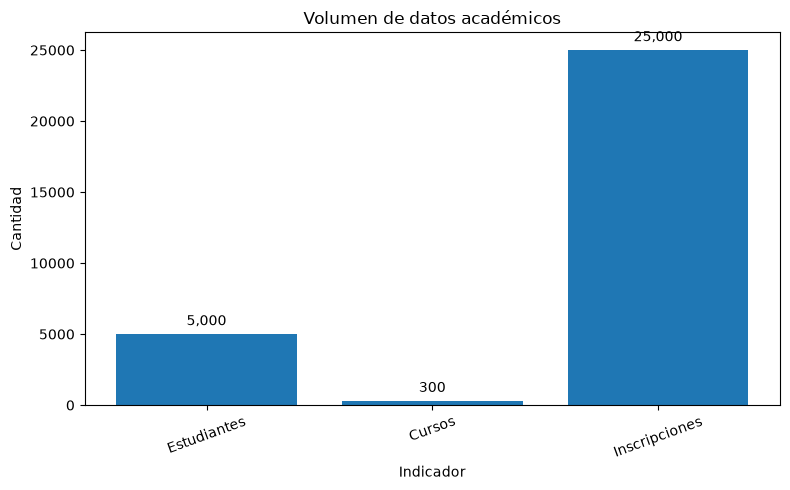

In [52]:
university_volumen_df = resumen_ejecutivo_df[
    resumen_ejecutivo_df["dominio"] == "University"
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    university_volumen_df["indicador"],
    university_volumen_df["valor"]
)

ax.set_title("Volumen de datos académicos")
ax.set_xlabel("Indicador")
ax.set_ylabel("Cantidad")

agregar_etiquetas_barras(ax)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Gráfico para Billing

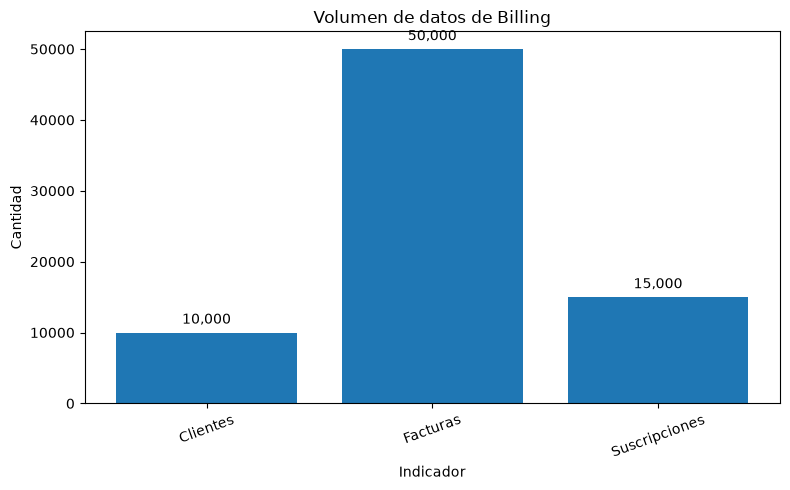

In [53]:
billing_volumen_df = resumen_ejecutivo_df[
    resumen_ejecutivo_df["dominio"] == "Billing"
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    billing_volumen_df["indicador"],
    billing_volumen_df["valor"]
)

ax.set_title("Volumen de datos de Billing")
ax.set_xlabel("Indicador")
ax.set_ylabel("Cantidad")

agregar_etiquetas_barras(ax)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Gráfico para CRM

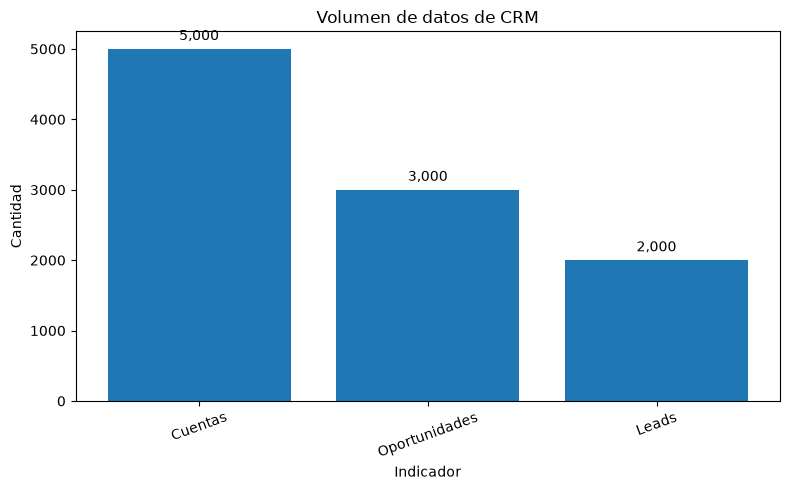

In [54]:
crm_volumen_df = resumen_ejecutivo_df[
    resumen_ejecutivo_df["dominio"] == "CRM"
]

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    crm_volumen_df["indicador"],
    crm_volumen_df["valor"]
)

ax.set_title("Volumen de datos de CRM")
ax.set_xlabel("Indicador")
ax.set_ylabel("Cantidad")

agregar_etiquetas_barras(ax)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Tasas ejecutivas en %

In [55]:
tasas_ejecutivas_df = pd.DataFrame({
    "indicador": [
        "Inscripciones completadas",
        "Inscripciones reprobadas",
        "Inscripciones abandonadas",
        "Facturas con estado paid",
        "Facturas paid subpagadas",
        "Suscripciones activas",
        "Oportunidades cerradas ganadas",
        "Leads convertidos"
    ],
    "tasa_pct": [
        kpis_df.loc[0, "enrollment_completion_rate_pct"],
        kpis_df.loc[0, "enrollment_failure_rate_pct"],
        kpis_df.loc[0, "enrollment_dropout_rate_pct"],
        kpis_df.loc[0, "paid_invoice_status_rate_pct"],
        kpis_df.loc[0, "paid_status_underpaid_rate_pct"],
        kpis_df.loc[0, "active_subscription_rate_pct"],
        kpis_df.loc[0, "closed_opportunity_win_rate_pct"],
        kpis_df.loc[0, "lead_conversion_rate_pct"]
    ]
})

tasas_ejecutivas_df

,indicador,tasa_pct
0,Inscripciones completadas,59.72
1,Inscripciones reprobadas,10.12
2,Inscripciones abandonadas,10.01
3,Facturas con estado paid,69.93
4,Facturas paid subpagadas,41.40
5,Suscripciones activas,75.15
6,Oportunidades cerradas ganadas,61.10
7,Leads convertidos,10.25


## Gráfico de tasas

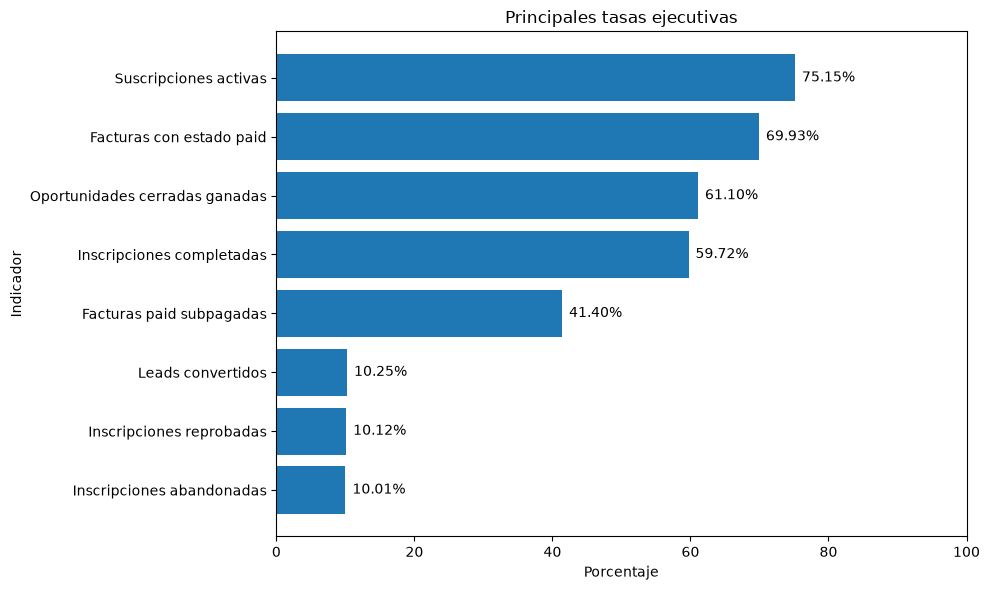

In [56]:
tasas_ordenadas_df = tasas_ejecutivas_df.sort_values(
    "tasa_pct"
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    tasas_ordenadas_df["indicador"],
    tasas_ordenadas_df["tasa_pct"]
)

ax.set_title("Principales tasas ejecutivas")
ax.set_xlabel("Porcentaje")
ax.set_ylabel("Indicador")
ax.set_xlim(0, 100)

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:.2f}%",
        (
            valor,
            barra.get_y() + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Interpretación de los KPIs ejecutivos
- El 59,72 % de las inscripciones tiene estado "completed".
- El 10,12 % tiene estado "failed".
- El 10,01 % tiene estado "dropped".
- El 69,93 % de las facturas figura con estado "paid".
- El 41,40 % de las facturas marcadas como "paid" tiene un pago acumulado inferior al total registrado.
- El 75,15 % de las suscripciones se encuentra activo.
- La tasa de ganancia entre oportunidades cerradas es del 61,10 %.
- El 10,25 % de los leads tiene estado actual "converted".

El principal HALLAZGO ejecutivo se encuentra en Billing: el estado administrativo de una factura no garantiza que el importe haya sido completamente pagado.

# 2. Análisis de University

Esta sección analiza el comportamiento académico desde dos niveles:
- Rendimiento general de las inscripciones.
- Desempeño por curso.
- Situación académica por estudiante.

El promedio utilizado corresponde al promedio ponderado de las evaluaciones disponibles. No representa necesariamente una nota final oficial, debido a que los pesos registrados no siempre suman 1.

In [57]:
query_courses = """
SELECT *
FROM gold.vw_course_performance_dashboard
ORDER BY course_code;
"""

courses_df = ejecutar_consulta(query_courses)


query_students = """
SELECT
    student_id,
    student_name,
    country,
    total_enrollments,
    completed_enrollments,
    active_enrollments,
    failed_enrollments,
    dropped_enrollments,
    repeated_combination_enrollments,
    enrollments_with_grades,
    average_weighted_observed_score
FROM gold.student_academic_summary;
"""

students_df = ejecutar_consulta(query_students)

print(
    f"Cursos analizados: {len(courses_df):,}"
)

print(
    f"Estudiantes analizados: {len(students_df):,}"
)

Cursos analizados: 300
Estudiantes analizados: 5,000


/tmp/ipykernel_2287/947915564.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


## Estados académicos

In [58]:
academic_status_df = pd.DataFrame({
    "estado": [
        "Completed",
        "Active",
        "Failed",
        "Dropped"
    ],
    "inscripciones": [
        kpis_df.loc[0, "completed_enrollments"],
        kpis_df.loc[0, "active_enrollments"],
        kpis_df.loc[0, "failed_enrollments"],
        kpis_df.loc[0, "dropped_enrollments"]
    ]
})

academic_status_df["porcentaje"] = (
    academic_status_df["inscripciones"]
    / academic_status_df["inscripciones"].sum()
    * 100
).round(2)

academic_status_df

,estado,inscripciones,porcentaje
0,Completed,14931,59.72
1,Active,5035,20.14
2,Failed,2531,10.12
3,Dropped,2503,10.01


## Gráfico de estados académicos

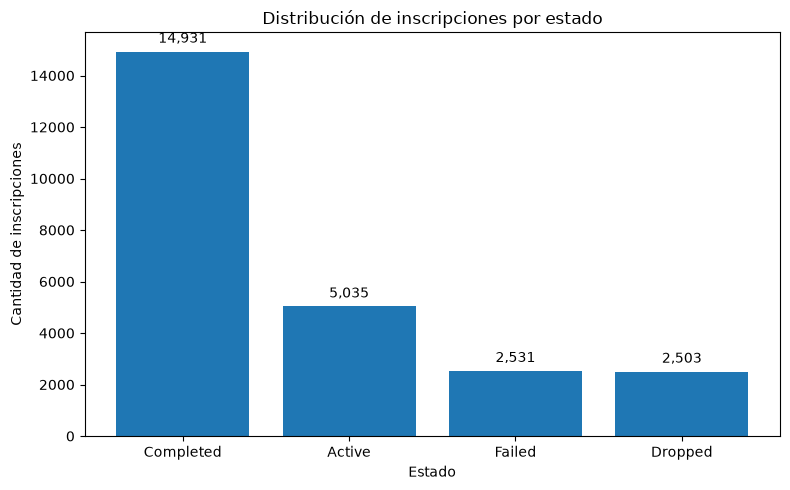

In [59]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    academic_status_df["estado"],
    academic_status_df["inscripciones"]
)

ax.set_title(
    "Distribución de inscripciones por estado"
)
ax.set_xlabel("Estado")
ax.set_ylabel("Cantidad de inscripciones")

agregar_etiquetas_barras(ax)

plt.tight_layout()
plt.show()

## Cursos con mayor cantidad de inscritos

In [60]:
top_courses_volume_df = (
    courses_df[
        [
            "course_code",
            "course_name",
            "professor_name",
            "department",
            "total_enrollments",
            "completed_enrollments",
            "failed_enrollments",
            "dropped_enrollments"
        ]
    ]
    .sort_values(
        "total_enrollments",
        ascending=False
    )
    .head(10)
)

top_courses_volume_df

,course_code,course_name,professor_name,department,total_enrollments,completed_enrollments,failed_enrollments,dropped_enrollments
189,C-00190,Course 00190,Manuel Morales,chemistry,108,61,15,14
52,C-00053,Course 00053,Sofia Valenzuela,history,108,59,9,18
41,C-00042,Course 00042,Maximiliano Reyes,physics,105,61,11,7
244,C-00245,Course 00245,Magdalena Cordero,history,104,67,14,7
9,C-00010,Course 00010,Manuel Tapia,cs,104,70,12,5
238,C-00239,Course 00239,Alejandro Arancibia,physics,104,62,5,12
49,C-00050,Course 00050,Rodrigo Cortes,economics,103,64,11,10
48,C-00049,Course 00049,Constanza Riquelme,cs,102,57,10,7
128,C-00129,Course 00129,Ana Cortes,math,100,48,14,16
191,C-00192,Course 00192,Gabriel Sepulveda,physics,100,68,12,8


## Gŕafico de cursos con mayor inscritos

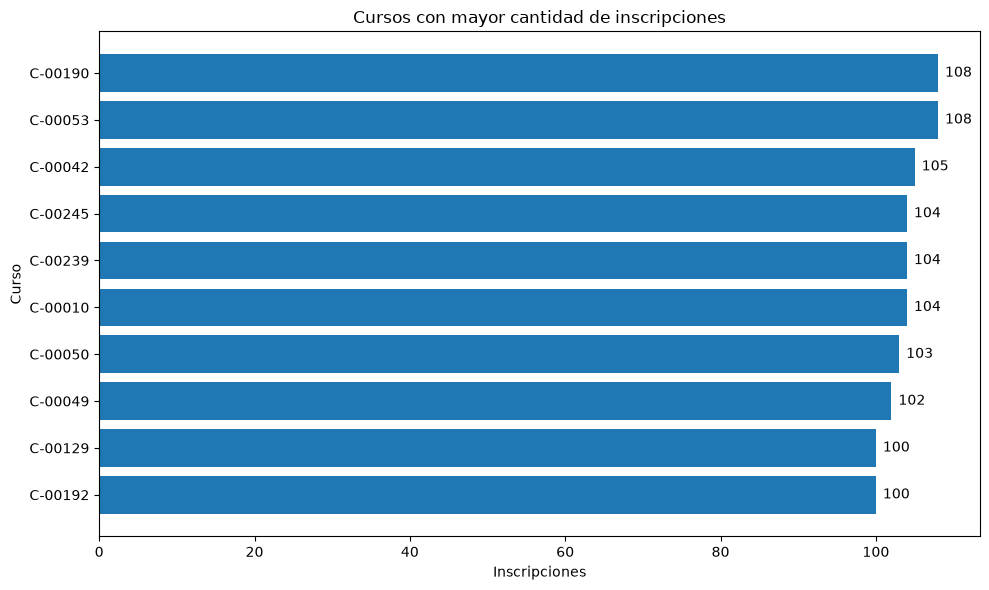

In [61]:
top_courses_volume_plot_df = (
    top_courses_volume_df
    .sort_values("total_enrollments")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_courses_volume_plot_df["course_code"],
    top_courses_volume_plot_df["total_enrollments"]
)

ax.set_title(
    "Cursos con mayor cantidad de inscripciones"
)
ax.set_xlabel("Inscripciones")
ax.set_ylabel("Curso")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:,.0f}",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Cursos con mayor tasa de reprobación

In [62]:
courses_failure_df = (
    courses_df[
        courses_df["total_enrollments"] >= 50
    ][
        [
            "course_code",
            "course_name",
            "professor_name",
            "department",
            "total_enrollments",
            "failed_enrollments",
            "failure_rate_pct",
            "average_weighted_observed_score"
        ]
    ]
    .sort_values(
        "failure_rate_pct",
        ascending=False
    )
    .head(10)
)

courses_failure_df

,course_code,course_name,professor_name,department,total_enrollments,failed_enrollments,failure_rate_pct,average_weighted_observed_score
94,C-00095,Course 00095,Macarena Soto,physics,70,17,24.29,74.56
82,C-00083,Course 00083,Juan Carvajal,literature,99,21,21.21,74.26
173,C-00174,Course 00174,Maria Espinoza,biology,76,16,21.05,76.07
100,C-00101,Course 00101,Alejandro Araya,math,91,17,18.68,75.64
59,C-00060,Course 00060,Alejandro Valenzuela,biology,78,14,17.95,76.39
231,C-00232,Course 00232,Rodrigo Sandoval,economics,73,13,17.81,74.13
77,C-00078,Course 00078,Fernanda Contreras,physics,75,13,17.33,74.45
249,C-00250,Course 00250,Sebastian Gomez,chemistry,75,13,17.33,75.40
35,C-00036,Course 00036,Ignacio Rodriguez,literature,93,16,17.20,74.27
185,C-00186,Course 00186,Renata Carrasco,chemistry,90,15,16.67,75.16


## Gráfico de reprobación por curso

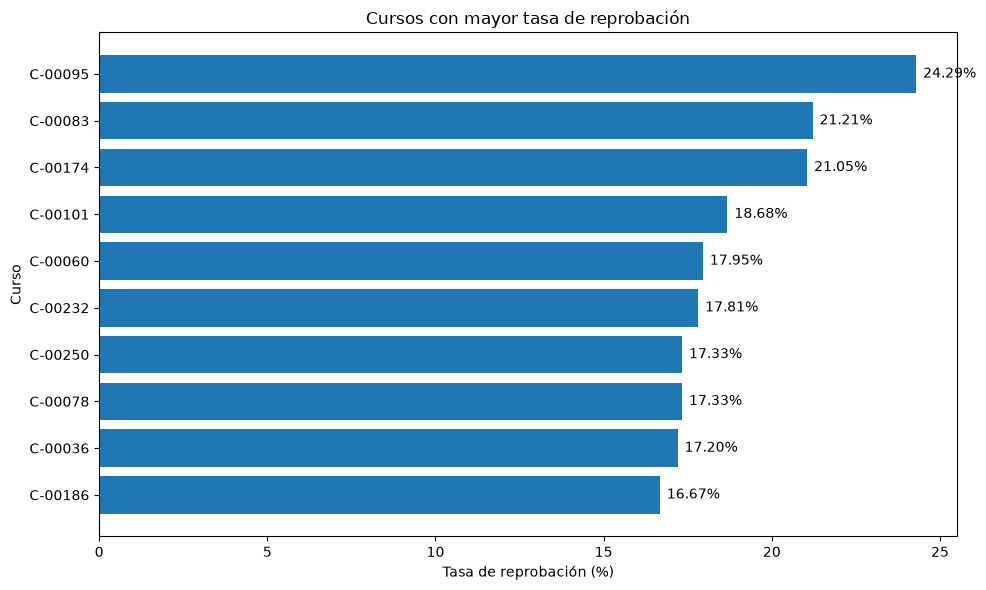

In [63]:
courses_failure_plot_df = (
    courses_failure_df
    .sort_values("failure_rate_pct")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    courses_failure_plot_df["course_code"],
    courses_failure_plot_df["failure_rate_pct"]
)

ax.set_title(
    "Cursos con mayor tasa de reprobación"
)
ax.set_xlabel("Tasa de reprobación (%)")
ax.set_ylabel("Curso")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:.2f}%",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Cursos con mayor tasa de abandono

In [64]:
courses_dropout_df = (
    courses_df[
        courses_df["total_enrollments"] >= 50
    ][
        [
            "course_code",
            "course_name",
            "professor_name",
            "department",
            "total_enrollments",
            "dropped_enrollments",
            "dropout_rate_pct",
            "average_weighted_observed_score"
        ]
    ]
    .sort_values(
        "dropout_rate_pct",
        ascending=False
    )
    .head(10)
)

courses_dropout_df

,course_code,course_name,professor_name,department,total_enrollments,dropped_enrollments,dropout_rate_pct,average_weighted_observed_score
200,C-00201,Course 00201,Andres Romero,chemistry,91,19,20.88,76.42
270,C-00271,Course 00271,Manuel Salazar,chemistry,92,18,19.57,75.13
158,C-00159,Course 00159,Martina Araya,economics,72,13,18.06,73.88
156,C-00157,Course 00157,Benjamin Pino,cs,85,15,17.65,74.50
47,C-00048,Course 00048,Ignacio Rodriguez,chemistry,91,16,17.58,72.93
280,C-00281,Course 00281,Daniel Araya,cs,97,17,17.53,73.88
218,C-00219,Course 00219,Daniela Salazar,biology,80,14,17.50,75.05
52,C-00053,Course 00053,Sofia Valenzuela,history,108,18,16.67,78.06
111,C-00112,Course 00112,Josefa Sepulveda,math,91,15,16.48,74.38
121,C-00122,Course 00122,Felipe Reyes,economics,86,14,16.28,75.66


## Gráfico de abandono por cursos

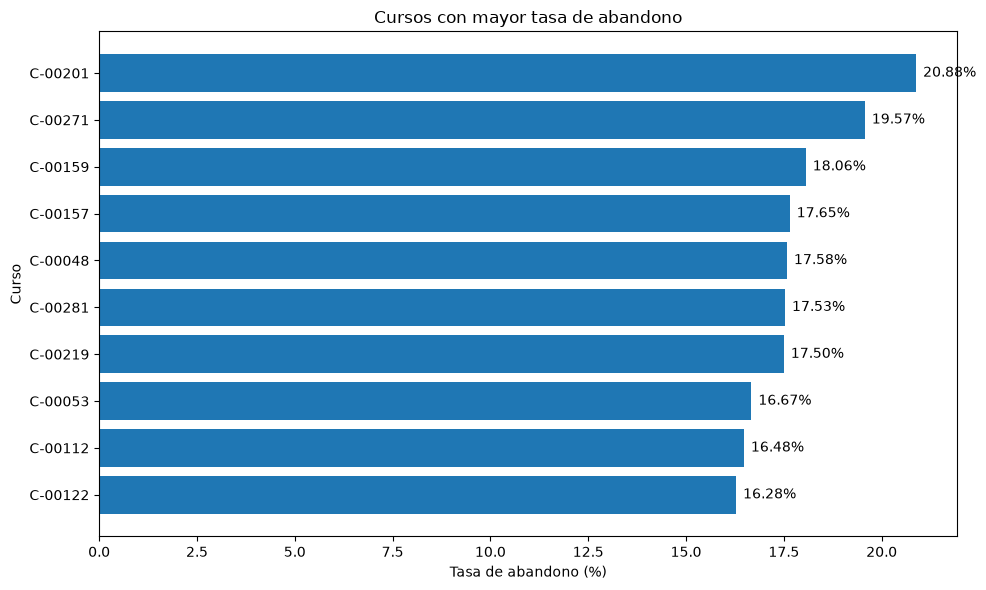

In [65]:
courses_dropout_plot_df = (
    courses_dropout_df
    .sort_values("dropout_rate_pct")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    courses_dropout_plot_df["course_code"],
    courses_dropout_plot_df["dropout_rate_pct"]
)

ax.set_title(
    "Cursos con mayor tasa de abandono"
)
ax.set_xlabel("Tasa de abandono (%)")
ax.set_ylabel("Curso")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:.2f}%",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Situación académica por estudiante
Esta clasificación no afirma que un estudiante no este "en riesgo". Solo identifica antecedentes de reprobación y abandono dentro de los datos disponibles.

In [66]:
def clasificar_situacion_academica(row):
    tiene_reprobacion = (
        row["failed_enrollments"] > 0
    )

    tiene_abandono = (
        row["dropped_enrollments"] > 0
    )

    if tiene_reprobacion and tiene_abandono:
        return "Reprobación y abandono"

    if tiene_reprobacion:
        return "Solo reprobación"

    if tiene_abandono:
        return "Solo abandono"

    return "Sin reprobación ni abandono"


students_df["situacion_academica"] = (
    students_df.apply(
        clasificar_situacion_academica,
        axis=1
    )
)

student_situation_df = (
    students_df["situacion_academica"]
    .value_counts()
    .rename_axis("situacion_academica")
    .reset_index(name="estudiantes")
)

student_situation_df["porcentaje"] = (
    student_situation_df["estudiantes"]
    / student_situation_df["estudiantes"].sum()
    * 100
).round(2)

student_situation_df

,situacion_academica,estudiantes,porcentaje
0,Sin reprobación ni abandono,1806,36.12
1,Solo reprobación,1230,24.60
2,Solo abandono,1189,23.78
3,Reprobación y abandono,775,15.50


## Gráfico de situación académica

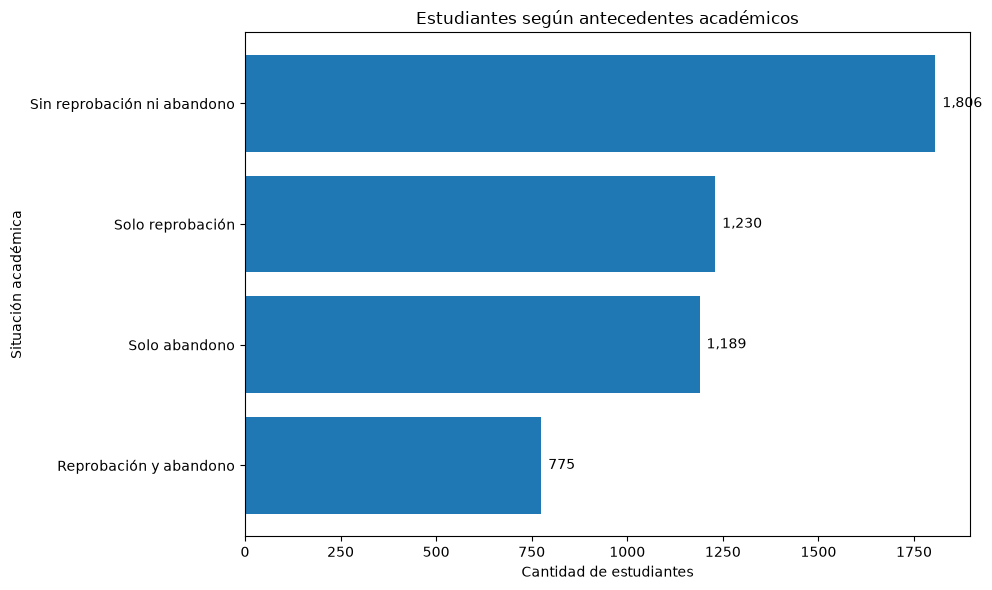

In [67]:
student_situation_plot_df = (
    student_situation_df
    .sort_values("estudiantes")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    student_situation_plot_df[
        "situacion_academica"
    ],
    student_situation_plot_df["estudiantes"]
)

ax.set_title(
    "Estudiantes según antecedentes académicos"
)
ax.set_xlabel("Cantidad de estudiantes")
ax.set_ylabel("Situación académica")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:,.0f}",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Distribución del promedio ponderado observado

In [68]:
observed_scores_df = students_df[
    students_df[
        "average_weighted_observed_score"
    ].notna()
].copy()

observed_scores_df[
    "average_weighted_observed_score"
].describe()

count   4,794.00
mean       74.86
std         5.57
min        49.24
25%        71.54
50%        74.94
75%        78.23
max       100.00
Name: average_weighted_observed_score, dtype: float64

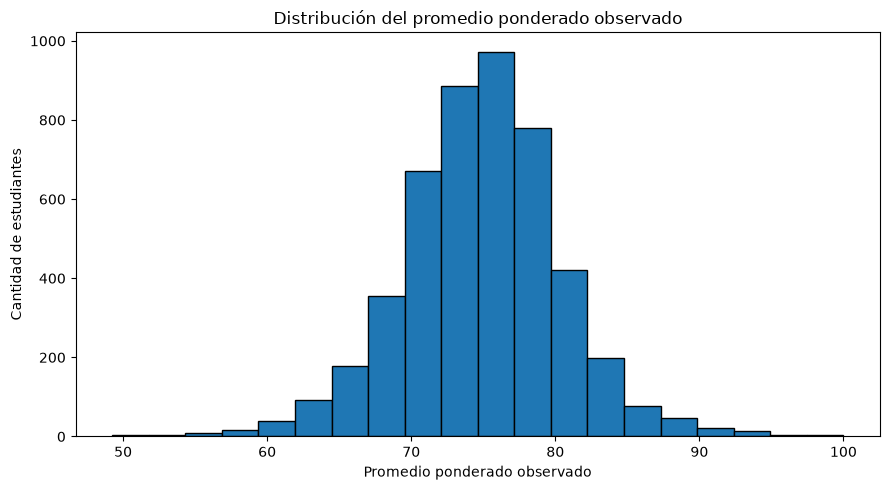

In [69]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    observed_scores_df[
        "average_weighted_observed_score"
    ],
    bins=20,
    edgecolor="black"
)

ax.set_title(
    "Distribución del promedio ponderado observado"
)
ax.set_xlabel("Promedio ponderado observado")
ax.set_ylabel("Cantidad de estudiantes")

plt.tight_layout()
plt.show()

## Hallazgos de University
- Se analizaron 5.000 estudiantes, 300 cursos y 25.000 inscripciones.
- El 59,72 % de las inscripciones está completado.
- Aproximadamente una quinta parte de las inscripciones permanece activa.
- Las tasas de reprobación y abandono son cercanas al 10 %.
- Los cursos con mayores tasas de reprobación o abandono pueden utilizarse para priorizar una revisión académica.
- La clasificación por estudiante es descriptiva y permite identificarantecedentes de reprobación, abandono o los 2.
- El promedio ponderado observado se calcula únicamente con las evaluaciones registradas y no debe interpretarse como una nota final.

# 3. Análisis de Billing
Esta sección analiza:
- Estados de las facturas.
- Conciliación entre facturas y pagos.
- Indicadores separados por moneda.
- Calidad de los items de factura.
- Estados de las suscripciones.
- Suscripciones activas asociadas a productos inactivos.

Los importes no se suman entre monedas diferentes, porque el origen no proporciona tipos de cambio.

In [70]:
query_billing_currency = """
SELECT *
FROM gold.billing_currency_kpis
ORDER BY currency;
"""

billing_currency_df = ejecutar_consulta(
    query_billing_currency
)

billing_currency_df

/tmp/ipykernel_2287/947915564.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


,currency,customers,total_invoices,paid_invoices,pending_invoices,overdue_invoices,total_payments,total_invoiced,total_paid,net_balance_amount,outstanding_amount,overpaid_amount,overpaid_invoices,exactly_paid_invoices,underpaid_invoices,paid_status_but_underpaid,open_status_but_fully_paid,invoices_without_items,invoices_matching_item_total,invoices_not_matching_item_total,paid_invoice_rate_pct,overdue_invoice_rate_pct,overpaid_invoice_rate_pct,underpaid_invoice_rate_pct,invoice_item_mismatch_rate_pct,kpi_created_at
0,ARS,2189,2456,1702,517,237,3994,"341,105.60","340,015.91","1,089.69","153,874.31","152,784.62",1015,0,1441,687,0,121,0,2335,69.30,9.65,41.33,58.67,100.00,2026-07-21 00:26:45.969448+00:00
1,BRL,2151,2412,1642,514,256,3751,"316,604.91","299,778.42","16,826.49","143,770.81","126,944.32",948,0,1464,694,0,113,0,2299,68.08,10.61,39.30,60.70,100.00,2026-07-21 00:26:45.969448+00:00
2,CLP,7782,15099,10575,3000,1524,24247,"2,068,001.06","1,974,219.12","93,781.94","932,910.91","839,128.97",6231,3,8865,4341,0,811,1,14287,70.04,10.09,41.27,58.71,99.99,2026-07-21 00:26:45.969448+00:00
3,COP,2240,2540,1779,502,259,4036,"335,107.14","324,059.42","11,047.72","153,924.09","142,876.37",1040,1,1499,738,0,121,0,2419,70.04,10.20,40.94,59.02,100.00,2026-07-21 00:26:45.969448+00:00
4,EUR,3931,5000,3446,1046,508,7900,"681,957.77","636,489.03","45,468.74","311,376.26","265,907.52",2014,1,2985,1431,0,232,0,4768,68.92,10.16,40.28,59.70,100.00,2026-07-21 00:26:45.969448+00:00
5,MXN,3852,4876,3420,959,497,7920,"643,041.86","616,845.87","26,195.99","283,740.32","257,544.33",2006,0,2870,1414,0,228,0,4648,70.14,10.19,41.14,58.86,100.00,2026-07-21 00:26:45.969448+00:00
6,PEN,2199,2455,1753,473,229,3894,"330,881.77","320,349.46","10,532.31","146,847.28","136,314.97",1001,0,1454,752,0,123,0,2332,71.41,9.33,40.77,59.23,100.00,2026-07-21 00:26:45.969448+00:00
7,USD,7803,15162,10649,3037,1476,24258,"2,075,150.03","1,981,927.49","93,222.54","932,276.73","839,054.19",6227,3,8932,4419,0,753,0,14409,70.23,9.73,41.07,58.91,100.00,2026-07-21 00:26:45.969448+00:00


In [71]:
billing_numeric_columns = [
    "total_invoices",
    "paid_invoices",
    "pending_invoices",
    "overdue_invoices",
    "total_payments",
    "total_invoiced",
    "total_paid",
    "outstanding_amount",
    "overpaid_amount",
    "overpaid_invoices",
    "exactly_paid_invoices",
    "underpaid_invoices",
    "paid_invoice_rate_pct",
    "overdue_invoice_rate_pct",
    "overpaid_invoice_rate_pct",
    "underpaid_invoice_rate_pct",
    "invoice_item_mismatch_rate_pct"
]

for column in billing_numeric_columns:
    billing_currency_df[column] = pd.to_numeric(
        billing_currency_df[column]
    )

## Estado de las facturas

In [72]:
invoice_status_df = pd.DataFrame({
    "estado": [
        "Paid",
        "Pending",
        "Overdue"
    ],
    "facturas": [
        kpis_df.loc[0, "paid_invoices"],
        kpis_df.loc[0, "pending_invoices"],
        kpis_df.loc[0, "overdue_invoices"]
    ]
})

invoice_status_df["porcentaje"] = (
    invoice_status_df["facturas"]
    / invoice_status_df["facturas"].sum()
    * 100
).round(2)

invoice_status_df

,estado,facturas,porcentaje
0,Paid,34966,69.93
1,Pending,10048,20.10
2,Overdue,4986,9.97


## Gráfico de los estados de las facturas

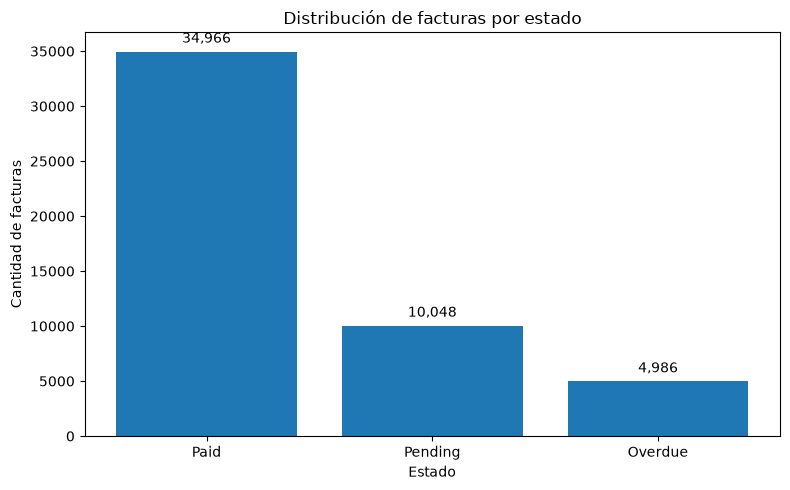

In [73]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    invoice_status_df["estado"],
    invoice_status_df["facturas"]
)

ax.set_title("Distribución de facturas por estado")
ax.set_xlabel("Estado")
ax.set_ylabel("Cantidad de facturas")

agregar_etiquetas_barras(ax)

plt.tight_layout()
plt.show()

## Conciliación entre facturas y pagos

In [74]:
payment_reconciliation_df = pd.DataFrame({
    "clasificacion": [
        "Sobrepagadas",
        "Pagadas exactamente",
        "Subpagadas"
    ],
    "facturas": [
        kpis_df.loc[0, "overpaid_invoices"],
        kpis_df.loc[0, "exactly_paid_invoices"],
        kpis_df.loc[0, "underpaid_invoices"]
    ]
})

payment_reconciliation_df["porcentaje"] = (
    payment_reconciliation_df["facturas"]
    / payment_reconciliation_df["facturas"].sum()
    * 100
).round(2)

payment_reconciliation_df

,clasificacion,facturas,porcentaje
0,Sobrepagadas,20482,40.96
1,Pagadas exactamente,8,0.02
2,Subpagadas,29510,59.02


## Gráfico de conciliación

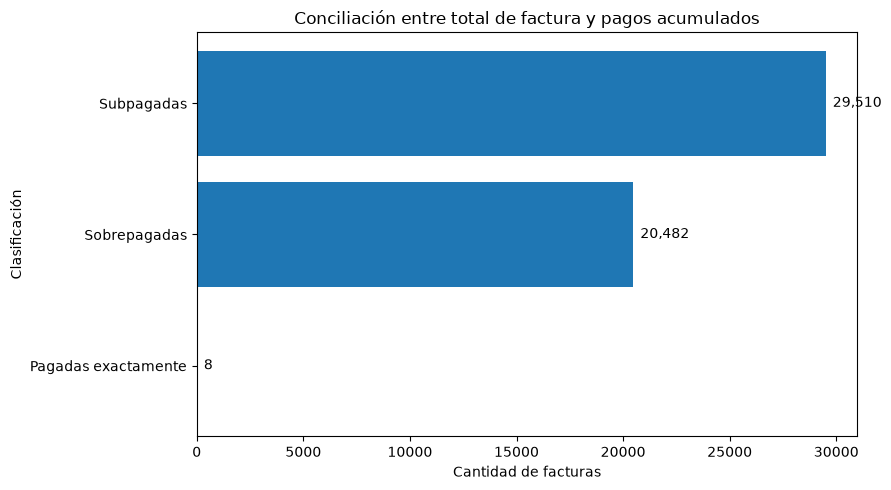

In [75]:
payment_reconciliation_plot_df = (
    payment_reconciliation_df
    .sort_values("facturas")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    payment_reconciliation_plot_df["clasificacion"],
    payment_reconciliation_plot_df["facturas"]
)

ax.set_title(
    "Conciliación entre total de factura y pagos acumulados"
)
ax.set_xlabel("Cantidad de facturas")
ax.set_ylabel("Clasificación")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:,.0f}",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Facturas paid que estan subpagadas

In [76]:
paid_status_df = pd.DataFrame({
    "indicador": [
        "Facturas con estado paid",
        "Paid pero subpagadas"
    ],
    "facturas": [
        kpis_df.loc[0, "paid_invoices"],
        kpis_df.loc[0, "paid_status_but_underpaid"]
    ]
})

paid_status_df

,indicador,facturas
0,Facturas con estado paid,34966
1,Paid pero subpagadas,14476


## Gráfico de facturas paid subpagadas

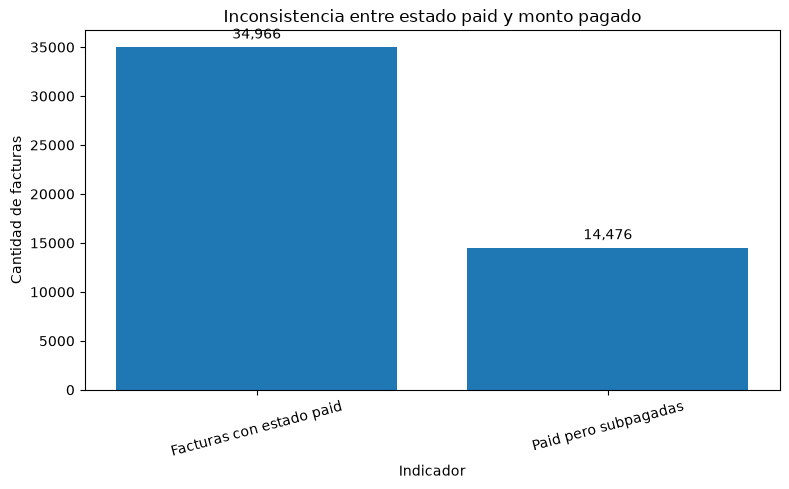

In [77]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    paid_status_df["indicador"],
    paid_status_df["facturas"]
)

ax.set_title(
    "Inconsistencia entre estado paid y monto pagado"
)
ax.set_xlabel("Indicador")
ax.set_ylabel("Cantidad de facturas")

agregar_etiquetas_barras(ax)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [78]:
paid_underpaid_rate = (
    kpis_df.loc[
        0,
        "paid_status_underpaid_rate_pct"
    ]
)

print(
    "Porcentaje de facturas paid que están "
    f"subpagadas: {paid_underpaid_rate:.2f}%"
)

Porcentaje de facturas paid que están subpagadas: 41.40%


## Indicadores por moneda
No se comparas los importes absolutos entre monedas. Se analiza las tasas y cobertura dentro de cada moneda.

In [79]:
billing_currency_analysis_df = (
    billing_currency_df[
        [
            "currency",
            "customers",
            "total_invoices",
            "total_payments",
            "total_invoiced",
            "total_paid",
            "outstanding_amount",
            "overpaid_amount",
            "paid_invoice_rate_pct",
            "overdue_invoice_rate_pct",
            "overpaid_invoice_rate_pct",
            "underpaid_invoice_rate_pct",
            "invoice_item_mismatch_rate_pct"
        ]
    ]
    .copy()
)

billing_currency_analysis_df["payment_coverage_pct"] = (
    billing_currency_analysis_df["total_paid"]
    / billing_currency_analysis_df["total_invoiced"]
    * 100
).round(2)

billing_currency_analysis_df

,currency,customers,total_invoices,total_payments,total_invoiced,total_paid,outstanding_amount,overpaid_amount,paid_invoice_rate_pct,overdue_invoice_rate_pct,overpaid_invoice_rate_pct,underpaid_invoice_rate_pct,invoice_item_mismatch_rate_pct,payment_coverage_pct
0,ARS,2189,2456,3994,"341,105.60","340,015.91","153,874.31","152,784.62",69.30,9.65,41.33,58.67,100.00,99.68
1,BRL,2151,2412,3751,"316,604.91","299,778.42","143,770.81","126,944.32",68.08,10.61,39.30,60.70,100.00,94.69
2,CLP,7782,15099,24247,"2,068,001.06","1,974,219.12","932,910.91","839,128.97",70.04,10.09,41.27,58.71,99.99,95.47
3,COP,2240,2540,4036,"335,107.14","324,059.42","153,924.09","142,876.37",70.04,10.20,40.94,59.02,100.00,96.70
4,EUR,3931,5000,7900,"681,957.77","636,489.03","311,376.26","265,907.52",68.92,10.16,40.28,59.70,100.00,93.33
5,MXN,3852,4876,7920,"643,041.86","616,845.87","283,740.32","257,544.33",70.14,10.19,41.14,58.86,100.00,95.93
6,PEN,2199,2455,3894,"330,881.77","320,349.46","146,847.28","136,314.97",71.41,9.33,40.77,59.23,100.00,96.82
7,USD,7803,15162,24258,"2,075,150.03","1,981,927.49","932,276.73","839,054.19",70.23,9.73,41.07,58.91,100.00,95.51


## Gráfico de cobertura de pagos por moneda

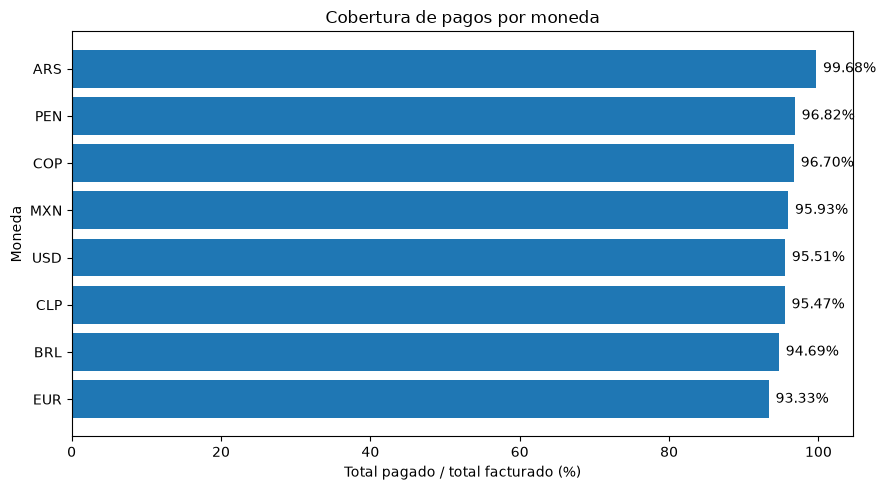

In [80]:
payment_coverage_plot_df = (
    billing_currency_analysis_df
    .sort_values("payment_coverage_pct")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    payment_coverage_plot_df["currency"],
    payment_coverage_plot_df["payment_coverage_pct"]
)

ax.set_title("Cobertura de pagos por moneda")
ax.set_xlabel("Total pagado / total facturado (%)")
ax.set_ylabel("Moneda")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:.2f}%",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Calidad de los items de factura

In [81]:
invoice_items_quality_df = pd.DataFrame({
    "clasificacion": [
        "Sin items",
        "Items coinciden",
        "Items no coinciden"
    ],
    "facturas": [
        kpis_df.loc[0, "invoices_without_items"],
        billing_currency_df[
            "invoices_matching_item_total"
        ].sum(),
        kpis_df.loc[
            0,
            "invoices_not_matching_item_total"
        ]
    ]
})

invoice_items_quality_df

,clasificacion,facturas
0,Sin items,2502
1,Items coinciden,1
2,Items no coinciden,47497


## Gráfico de calidad de items

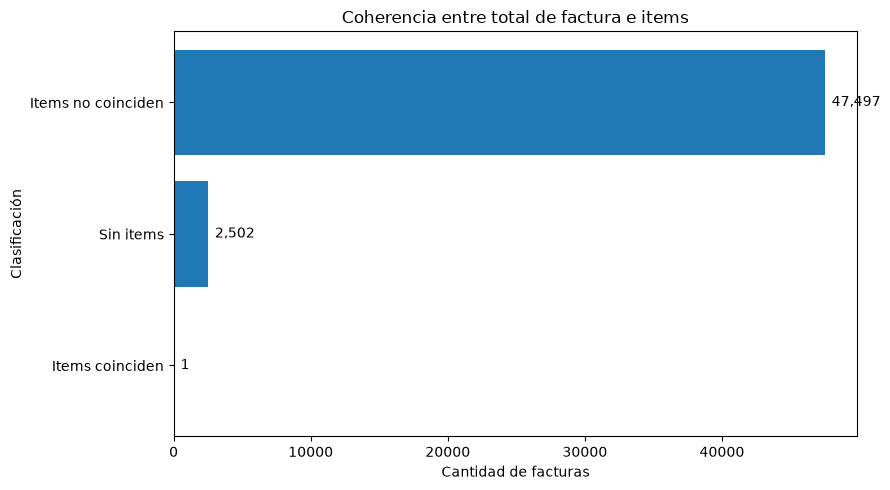

In [82]:
invoice_items_quality_plot_df = (
    invoice_items_quality_df
    .sort_values("facturas")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    invoice_items_quality_plot_df["clasificacion"],
    invoice_items_quality_plot_df["facturas"]
)

ax.set_title(
    "Coherencia entre total de factura e items"
)
ax.set_xlabel("Cantidad de facturas")
ax.set_ylabel("Clasificación")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:,.0f}",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Análisis de suscripciones

In [83]:
query_subscriptions = """
SELECT
    SUM(total_subscriptions) AS total_subscriptions,
    SUM(active_subscriptions) AS active_subscriptions,
    SUM(paused_subscriptions) AS paused_subscriptions,
    SUM(cancelled_subscriptions) AS cancelled_subscriptions,
    SUM(temporally_invalid_subscriptions)
        AS temporally_invalid_subscriptions,
    SUM(active_subscriptions_to_inactive_products)
        AS active_subscriptions_to_inactive_products,
    COUNT(*) FILTER (
        WHERE total_subscriptions = 0
    ) AS customers_without_subscriptions
FROM gold.customer_subscription_summary;
"""

subscription_kpis_df = ejecutar_consulta(
    query_subscriptions
)

subscription_kpis_df

/tmp/ipykernel_2287/947915564.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


,total_subscriptions,active_subscriptions,paused_subscriptions,cancelled_subscriptions,temporally_invalid_subscriptions,active_subscriptions_to_inactive_products,customers_without_subscriptions
0,"15,000.00","11,272.00","1,486.00","2,242.00",783.00,"1,753.00",2224


## Estados de suscripción

In [84]:
subscription_status_df = pd.DataFrame({
    "estado": [
        "Active",
        "Paused",
        "Cancelled"
    ],
    "suscripciones": [
        subscription_kpis_df.loc[
            0,
            "active_subscriptions"
        ],
        subscription_kpis_df.loc[
            0,
            "paused_subscriptions"
        ],
        subscription_kpis_df.loc[
            0,
            "cancelled_subscriptions"
        ]
    ]
})

subscription_status_df["porcentaje"] = (
    subscription_status_df["suscripciones"]
    / subscription_status_df["suscripciones"].sum()
    * 100
).round(2)

subscription_status_df

,estado,suscripciones,porcentaje
0,Active,"11,272.00",75.15
1,Paused,"1,486.00",9.91
2,Cancelled,"2,242.00",14.95


## Gráfico de suscripciones

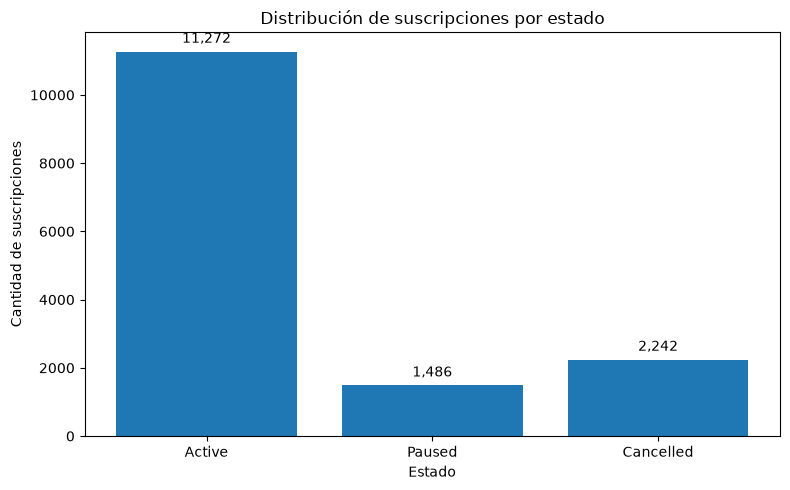

In [86]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    subscription_status_df["estado"],
    subscription_status_df["suscripciones"]
)

ax.set_title("Distribución de suscripciones por estado")
ax.set_xlabel("Estado")
ax.set_ylabel("Cantidad de suscripciones")

agregar_etiquetas_barras(ax)

plt.tight_layout()
plt.show()

## Suscripciones con situaciones para revisión

In [87]:
subscription_issues_df = pd.DataFrame({
    "situacion": [
        "Fechas inconsistentes",
        "Activas en productos inactivos"
    ],
    "suscripciones": [
        subscription_kpis_df.loc[
            0,
            "temporally_invalid_subscriptions"
        ],
        subscription_kpis_df.loc[
            0,
            "active_subscriptions_to_inactive_products"
        ]
    ]
})

subscription_issues_df

,situacion,suscripciones
0,Fechas inconsistentes,783.00
1,Activas en productos inactivos,"1,753.00"


## Gráfico de suscripciones con revisión

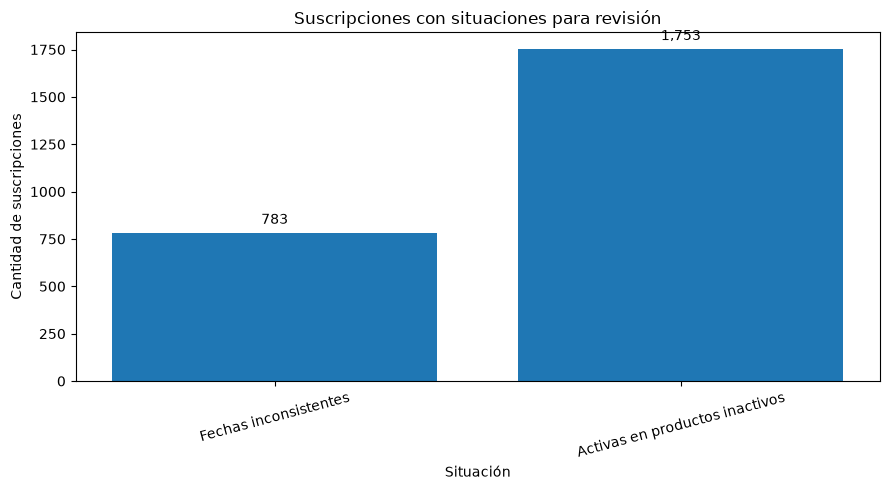

In [88]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    subscription_issues_df["situacion"],
    subscription_issues_df["suscripciones"]
)

ax.set_title(
    "Suscripciones con situaciones para revisión"
)
ax.set_xlabel("Situación")
ax.set_ylabel("Cantidad de suscripciones")

agregar_etiquetas_barras(ax)

plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## Hallazgos de Billing
- Se analizaron 50.000 facturas y 80.000 pagos.
- El 69,93 % de las facturas tiene estado "paid".
- Solo 8 facturas presentan una coincidencia exacta entre el total facturado y el pago acumulado.
- Se identificaron 20.482 facturas sobrepagadas y 29.510 subpagadas.
- El 41,40 % de las facturas con estado "paid" está subpagado.
- Existen 2.502 facturas sin items.
- La gran mayoría de las facturas con items presenta diferencias entre
  el total registrado y la suma de sus líneas.
- El 75,15 % de las suscripciones tiene estado "active".
- Se encontraron 783 suscripciones con inconsistencias temporales.
- Existen 1.753 suscripciones activas relacionadas con productos inactivos.
- Los importes se analizan por moneda y no se consolidan mediante una suma general.

# 4. Análisis de CRM
Esta sección analiza el desempeño comercial desde tres perspectivas:
- Oportunidades por etapa.
- Actividades y relaciones comerciales por cuenta.
- Leads y conversión por fuente.

El campo "amount" de las oportunidades no incluye una moneda explícita. Por esta razón, los valores se presentan como montos registrados en CRM y no se combinan con los importes de Billing.

In [89]:
query_crm_accounts = """
SELECT *
FROM gold.vw_crm_account_dashboard
ORDER BY account_id;
"""

crm_accounts_df = ejecutar_consulta(
    query_crm_accounts
)


query_leads = """
SELECT *
FROM gold.vw_lead_source_dashboard
ORDER BY source;
"""

leads_df = ejecutar_consulta(
    query_leads
)

print(
    f"Cuentas CRM analizadas: {len(crm_accounts_df):,}"
)

print(
    f"Fuentes de leads analizadas: {len(leads_df):,}"
)

Cuentas CRM analizadas: 5,000
Fuentes de leads analizadas: 5


/tmp/ipykernel_2287/947915564.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


In [90]:
crm_numeric_columns = [
    "annual_revenue",
    "employees",
    "total_contacts",
    "total_opportunities",
    "prospect_opportunities",
    "qualification_opportunities",
    "proposal_opportunities",
    "negotiation_opportunities",
    "won_opportunities",
    "lost_opportunities",
    "open_opportunities",
    "total_crm_opportunity_amount",
    "won_crm_amount",
    "lost_crm_amount",
    "open_pipeline_crm_amount",
    "average_crm_opportunity_amount",
    "closed_opportunity_win_rate_pct",
    "temporally_invalid_opportunities",
    "opportunity_contact_relationships",
    "same_account_relationships",
    "different_account_relationships",
    "total_activities",
    "call_activities",
    "demo_activities",
    "email_activities",
    "meeting_activities",
    "note_activities"
]

for column in crm_numeric_columns:
    crm_accounts_df[column] = pd.to_numeric(
        crm_accounts_df[column]
    )


lead_numeric_columns = [
    "total_leads",
    "new_leads",
    "contacted_leads",
    "qualified_leads",
    "converted_leads",
    "lost_leads",
    "average_lead_score",
    "conversion_rate_pct",
    "qualified_or_converted_rate_pct",
    "leads_with_quality_issue"
]

for column in lead_numeric_columns:
    leads_df[column] = pd.to_numeric(
        leads_df[column]
    )

## Oportunidades

In [91]:
opportunity_stage_df = pd.DataFrame({
    "etapa": [
        "Prospect",
        "Qualification",
        "Proposal",
        "Negotiation",
        "Won",
        "Lost"
    ],
    "oportunidades": [
        crm_accounts_df[
            "prospect_opportunities"
        ].sum(),
        crm_accounts_df[
            "qualification_opportunities"
        ].sum(),
        crm_accounts_df[
            "proposal_opportunities"
        ].sum(),
        crm_accounts_df[
            "negotiation_opportunities"
        ].sum(),
        crm_accounts_df[
            "won_opportunities"
        ].sum(),
        crm_accounts_df[
            "lost_opportunities"
        ].sum()
    ]
})

opportunity_stage_df["porcentaje"] = (
    opportunity_stage_df["oportunidades"]
    / opportunity_stage_df["oportunidades"].sum()
    * 100
).round(2)

opportunity_stage_df

,etapa,oportunidades,porcentaje
0,Prospect,621,20.70
1,Qualification,611,20.37
2,Proposal,569,18.97
3,Negotiation,420,14.00
4,Won,476,15.87
5,Lost,303,10.10


## Gráfico de oportunidades

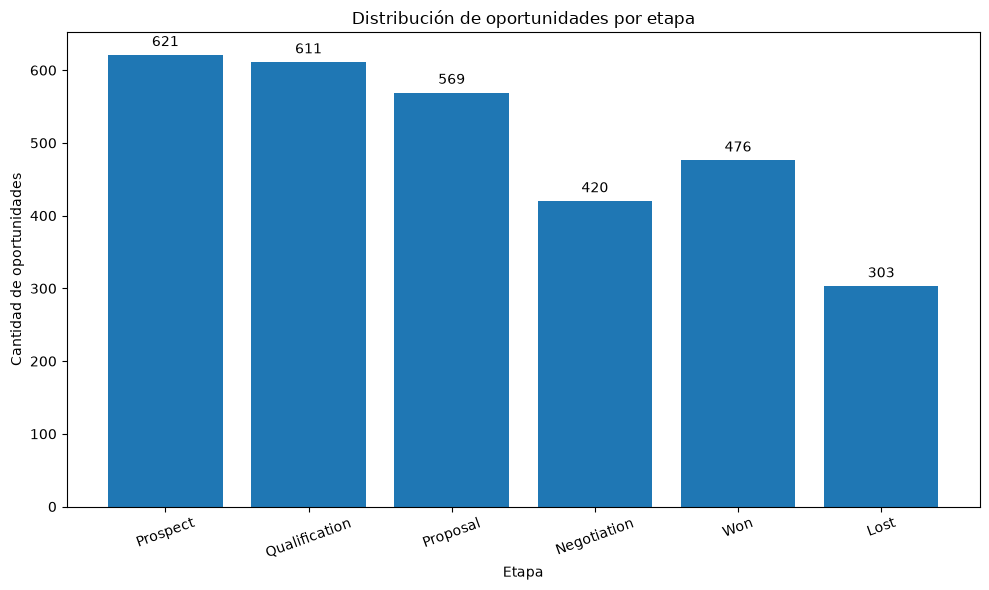

In [92]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.bar(
    opportunity_stage_df["etapa"],
    opportunity_stage_df["oportunidades"]
)

ax.set_title(
    "Distribución de oportunidades por etapa"
)
ax.set_xlabel("Etapa")
ax.set_ylabel("Cantidad de oportunidades")

agregar_etiquetas_barras(ax)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Oportunidades abiertas y cerradas

In [93]:
opportunity_status_df = pd.DataFrame({
    "clasificacion": [
        "Abiertas",
        "Ganadas",
        "Perdidas"
    ],
    "oportunidades": [
        crm_accounts_df[
            "open_opportunities"
        ].sum(),
        crm_accounts_df[
            "won_opportunities"
        ].sum(),
        crm_accounts_df[
            "lost_opportunities"
        ].sum()
    ]
})

opportunity_status_df["porcentaje"] = (
    opportunity_status_df["oportunidades"]
    / opportunity_status_df["oportunidades"].sum()
    * 100
).round(2)

opportunity_status_df

,clasificacion,oportunidades,porcentaje
0,Abiertas,2221,74.03
1,Ganadas,476,15.87
2,Perdidas,303,10.10


## Gráfico de oportunidades abiertas y cerradas

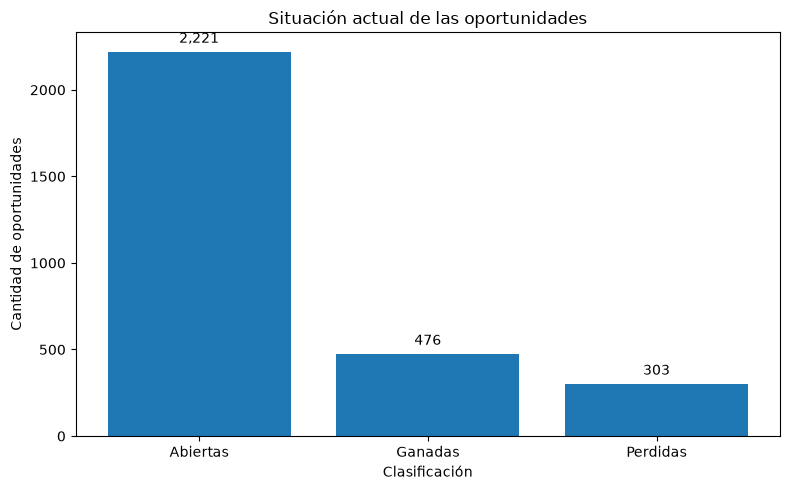

In [94]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    opportunity_status_df["clasificacion"],
    opportunity_status_df["oportunidades"]
)

ax.set_title(
    "Situación actual de las oportunidades"
)
ax.set_xlabel("Clasificación")
ax.set_ylabel("Cantidad de oportunidades")

agregar_etiquetas_barras(ax)

plt.tight_layout()
plt.show()

## Tasa de ganancia
La tasa se calcula únicamente sobre oportunidades cerradas: (won/won+lost)

In [95]:
won_opportunities = crm_accounts_df[
    "won_opportunities"
].sum()

lost_opportunities = crm_accounts_df[
    "lost_opportunities"
].sum()

closed_opportunities = (
    won_opportunities
    + lost_opportunities
)

win_rate = (
    won_opportunities
    / closed_opportunities
    * 100
)

print(
    f"Oportunidades cerradas: "
    f"{closed_opportunities:,.0f}"
)

print(
    f"Oportunidades ganadas: "
    f"{won_opportunities:,.0f}"
)

print(
    f"Tasa de ganancia: "
    f"{win_rate:.2f}%"
)

Oportunidades cerradas: 779
Oportunidades ganadas: 476
Tasa de ganancia: 61.10%


## Montos registrados en CRM

In [96]:
crm_amounts_df = pd.DataFrame({
    "clasificacion": [
        "Pipeline abierto",
        "Ganado",
        "Perdido"
    ],
    "monto_crm": [
        crm_accounts_df[
            "open_pipeline_crm_amount"
        ].sum(),
        crm_accounts_df[
            "won_crm_amount"
        ].sum(),
        crm_accounts_df[
            "lost_crm_amount"
        ].sum()
    ]
})

crm_amounts_df

,clasificacion,monto_crm
0,Pipeline abierto,"83,464,415.86"
1,Ganado,"18,360,511.13"
2,Perdido,"11,940,870.10"


## Gráfico de montos registrados

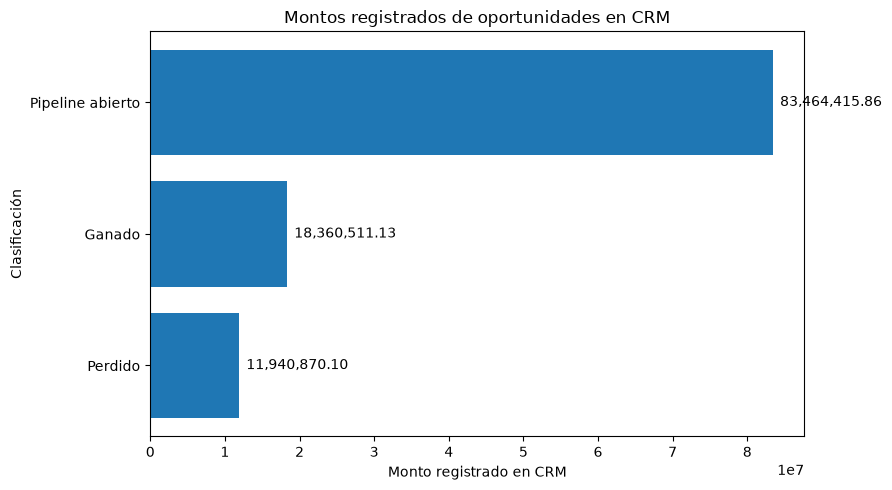

In [97]:
crm_amounts_plot_df = (
    crm_amounts_df
    .sort_values("monto_crm")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    crm_amounts_plot_df["clasificacion"],
    crm_amounts_plot_df["monto_crm"]
)

ax.set_title(
    "Montos registrados de oportunidades en CRM"
)
ax.set_xlabel("Monto registrado en CRM")
ax.set_ylabel("Clasificación")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:,.2f}",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Cuentas con mayor pipeline abierto

In [98]:
top_open_pipeline_df = (
    crm_accounts_df[
        [
            "account_id",
            "account_name",
            "industry",
            "country",
            "open_opportunities",
            "open_pipeline_crm_amount",
            "total_activities"
        ]
    ]
    .sort_values(
        "open_pipeline_crm_amount",
        ascending=False
    )
    .head(10)
)

top_open_pipeline_df

,account_id,account_name,industry,country,open_opportunities,open_pipeline_crm_amount,total_activities
2624,ACC-0002625,Maya Partners,tech,PE,1,"541,485.25",8
884,ACC-0000885,Vertex Solutions,energy,AR,3,"495,732.95",10
1350,ACC-0001351,Norte Foods,finance,MX,1,"486,753.03",1
1254,ACC-0001255,Plata Labs,education,CO,2,"444,154.24",9
1120,ACC-0001121,Plata SpA,retail,ES,1,"407,801.51",1
4731,ACC-0004732,Plata Group,retail,CO,2,"397,784.14",9
4898,ACC-0004899,Maipo SpA,tech,BR,2,"381,897.16",11
3234,ACC-0003235,Prima Data,tech,MX,1,"368,549.23",9
1027,ACC-0001028,Solar SpA,finance,CL,1,"348,679.87",4
4707,ACC-0004708,Vino Group,services,CL,1,"346,910.40",9


## Gráfico del mayor pipeline abierto

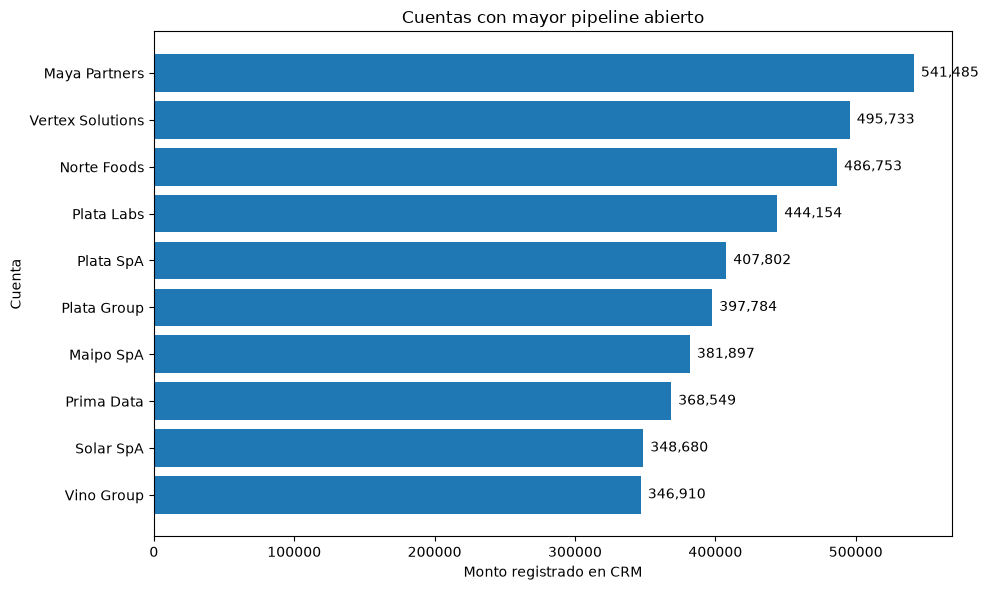

In [99]:
top_open_pipeline_plot_df = (
    top_open_pipeline_df
    .sort_values("open_pipeline_crm_amount")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    top_open_pipeline_plot_df["account_name"],
    top_open_pipeline_plot_df[
        "open_pipeline_crm_amount"
    ]
)

ax.set_title(
    "Cuentas con mayor pipeline abierto"
)
ax.set_xlabel("Monto registrado en CRM")
ax.set_ylabel("Cuenta")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:,.0f}",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Calidad temporal de oportunidades

In [100]:
opportunity_temporal_df = pd.DataFrame({
    "clasificacion": [
        "Fechas válidas",
        "Fechas inconsistentes"
    ],
    "oportunidades": [
        kpis_df.loc[
            0,
            "total_opportunities"
        ]
        - kpis_df.loc[
            0,
            "temporally_invalid_opportunities"
        ],
        kpis_df.loc[
            0,
            "temporally_invalid_opportunities"
        ]
    ]
})

opportunity_temporal_df["porcentaje"] = (
    opportunity_temporal_df["oportunidades"]
    / opportunity_temporal_df["oportunidades"].sum()
    * 100
).round(2)

opportunity_temporal_df

,clasificacion,oportunidades,porcentaje
0,Fechas válidas,1971,65.70
1,Fechas inconsistentes,1029,34.30


## Gráfico de calidad temporal de oportunidades

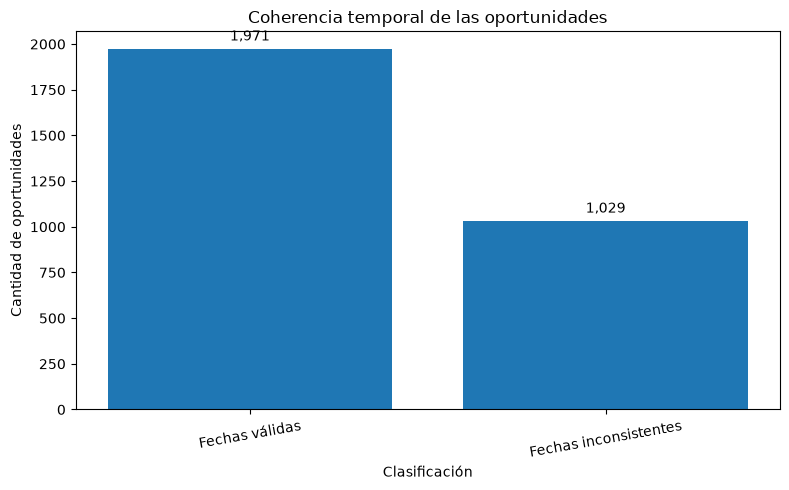

In [102]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    opportunity_temporal_df["clasificacion"],
    opportunity_temporal_df["oportunidades"]
)

ax.set_title(
    "Coherencia temporal de las oportunidades"
)
ax.set_xlabel("Clasificación")
ax.set_ylabel("Cantidad de oportunidades")

agregar_etiquetas_barras(ax)

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

Tasa de inconsistencia temporal:

In [103]:
temporal_issue_rate = (
    kpis_df.loc[
        0,
        "temporally_invalid_opportunities"
    ]
    / kpis_df.loc[
        0,
        "total_opportunities"
    ]
    * 100
)

print(
    "Oportunidades con fechas inconsistentes: "
    f"{temporal_issue_rate:.2f}%"
)

Oportunidades con fechas inconsistentes: 34.30%


## Relaciones entre oportunidades y contactos

In [104]:
opportunity_contact_df = pd.DataFrame({
    "clasificacion": [
        "Misma cuenta",
        "Cuenta diferente"
    ],
    "relaciones": [
        kpis_df.loc[
            0,
            "same_account_relationships"
        ],
        kpis_df.loc[
            0,
            "different_account_relationships"
        ]
    ]
})

opportunity_contact_df["porcentaje"] = (
    opportunity_contact_df["relaciones"]
    / opportunity_contact_df["relaciones"].sum()
    * 100
).round(2)

opportunity_contact_df

,clasificacion,relaciones,porcentaje
0,Misma cuenta,5,0.08
1,Cuenta diferente,5995,99.92


## Gráfico de relaciones

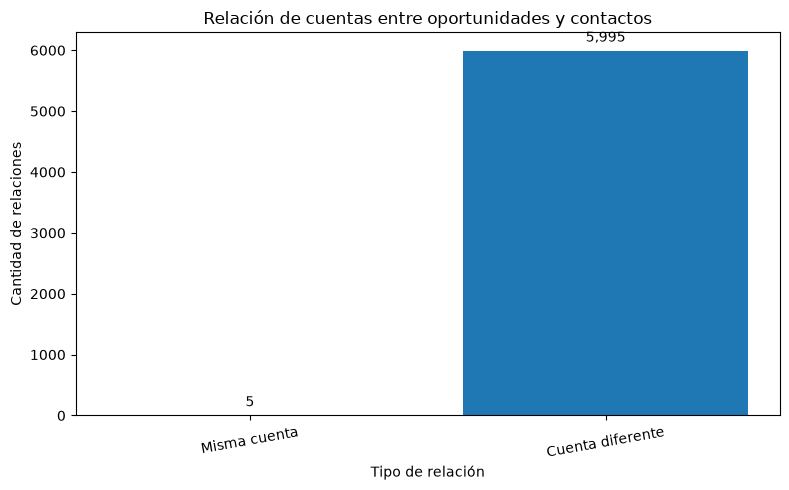

In [105]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    opportunity_contact_df["clasificacion"],
    opportunity_contact_df["relaciones"]
)

ax.set_title(
    "Relación de cuentas entre oportunidades y contactos"
)
ax.set_xlabel("Tipo de relación")
ax.set_ylabel("Cantidad de relaciones")

agregar_etiquetas_barras(ax)

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Actividades comerciales
### Distribución por tipo

In [106]:
activity_type_df = pd.DataFrame({
    "tipo": [
        "Call",
        "Demo",
        "Email",
        "Meeting",
        "Note"
    ],
    "actividades": [
        crm_accounts_df[
            "call_activities"
        ].sum(),
        crm_accounts_df[
            "demo_activities"
        ].sum(),
        crm_accounts_df[
            "email_activities"
        ].sum(),
        crm_accounts_df[
            "meeting_activities"
        ].sum(),
        crm_accounts_df[
            "note_activities"
        ].sum()
    ]
})

activity_type_df

,tipo,actividades
0,Call,5174
1,Demo,1647
2,Email,5906
3,Meeting,2570
4,Note,1722


## Gráfico de actividades asignadas

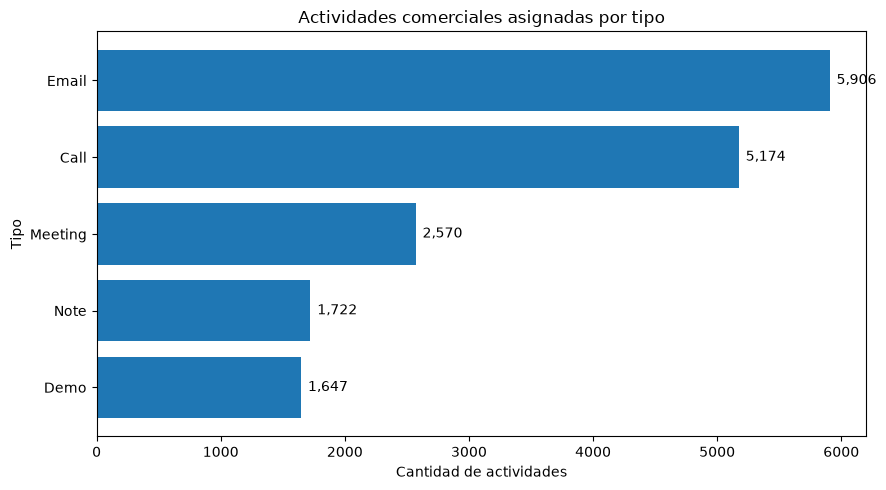

In [107]:
activity_type_plot_df = (
    activity_type_df
    .sort_values("actividades")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    activity_type_plot_df["tipo"],
    activity_type_plot_df["actividades"]
)

ax.set_title(
    "Actividades comerciales asignadas por tipo"
)
ax.set_xlabel("Cantidad de actividades")
ax.set_ylabel("Tipo")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:,.0f}",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Actividades asignadas y sin referencias

In [108]:
activity_assignment_df = pd.DataFrame({
    "clasificacion": [
        "Asignadas a una cuenta",
        "Sin referencia"
    ],
    "actividades": [
        kpis_df.loc[
            0,
            "assigned_activities"
        ],
        kpis_df.loc[
            0,
            "unassigned_activities"
        ]
    ]
})

activity_assignment_df["porcentaje"] = (
    activity_assignment_df["actividades"]
    / activity_assignment_df["actividades"].sum()
    * 100
).round(2)

activity_assignment_df

,clasificacion,actividades,porcentaje
0,Asignadas a una cuenta,17019,85.10
1,Sin referencia,2981,14.90


## Gráfico de asignación de actividades

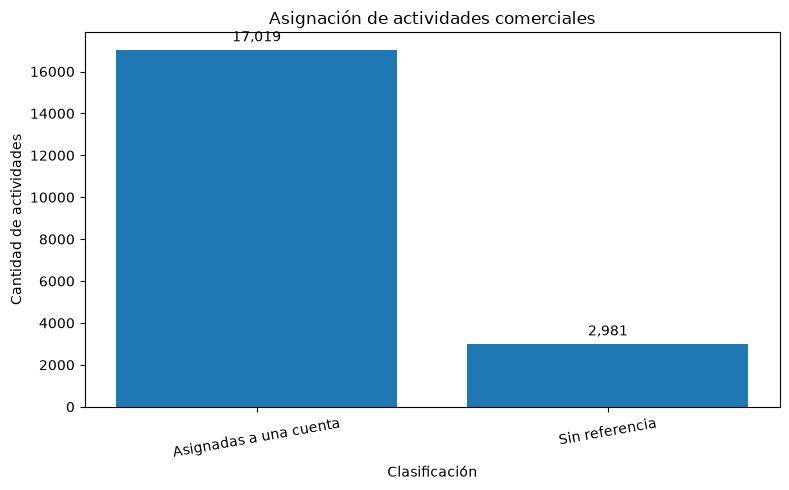

In [109]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    activity_assignment_df["clasificacion"],
    activity_assignment_df["actividades"]
)

ax.set_title(
    "Asignación de actividades comerciales"
)
ax.set_xlabel("Clasificación")
ax.set_ylabel("Cantidad de actividades")

agregar_etiquetas_barras(ax)

plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

## Análisis de leads
### Distribución general por estado

In [110]:
lead_status_df = pd.DataFrame({
    "estado": [
        "New",
        "Contacted",
        "Qualified",
        "Converted",
        "Lost"
    ],
    "leads": [
        leads_df["new_leads"].sum(),
        leads_df["contacted_leads"].sum(),
        leads_df["qualified_leads"].sum(),
        leads_df["converted_leads"].sum(),
        leads_df["lost_leads"].sum()
    ]
})

lead_status_df["porcentaje"] = (
    lead_status_df["leads"]
    / lead_status_df["leads"].sum()
    * 100
).round(2)

lead_status_df

,estado,leads,porcentaje
0,New,594,29.70
1,Contacted,525,26.25
2,Qualified,395,19.75
3,Converted,205,10.25
4,Lost,281,14.05


## Gráfico de leads por estado

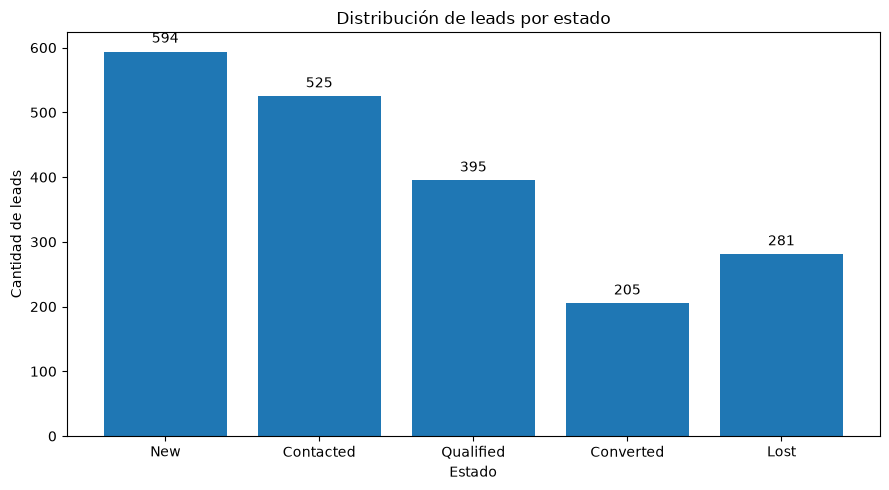

In [111]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(
    lead_status_df["estado"],
    lead_status_df["leads"]
)

ax.set_title("Distribución de leads por estado")
ax.set_xlabel("Estado")
ax.set_ylabel("Cantidad de leads")

agregar_etiquetas_barras(ax)

plt.tight_layout()
plt.show()

## Conversión por fuente

In [112]:
lead_source_analysis_df = (
    leads_df[
        [
            "source",
            "total_leads",
            "converted_leads",
            "qualified_leads",
            "average_lead_score",
            "conversion_rate_pct",
            "qualified_or_converted_rate_pct"
        ]
    ]
    .sort_values(
        "conversion_rate_pct",
        ascending=False
    )
)

lead_source_analysis_df

,source,total_leads,converted_leads,qualified_leads,average_lead_score,conversion_rate_pct,qualified_or_converted_rate_pct
1,cold_call,204,30,36,48.94,14.71,32.35
3,referral,402,46,91,49.40,11.44,34.08
2,event,302,32,53,50.97,10.60,28.15
0,ads,282,28,49,50.06,9.93,27.30
4,web,810,69,166,50.42,8.52,29.01


## Gráfico de conversión por fuente

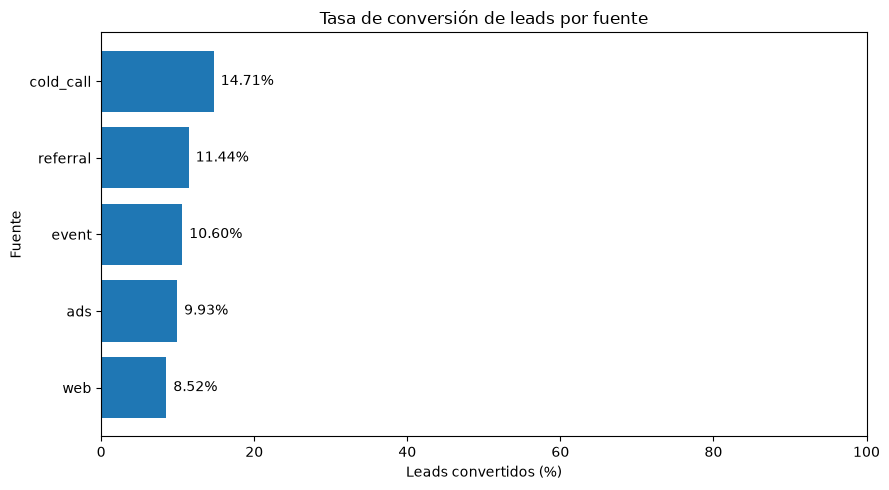

In [114]:
lead_conversion_plot_df = (
    lead_source_analysis_df
    .sort_values("conversion_rate_pct")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    lead_conversion_plot_df["source"],
    lead_conversion_plot_df[
        "conversion_rate_pct"
    ]
)

ax.set_title(
    "Tasa de conversión de leads por fuente"
)
ax.set_xlabel("Leads convertidos (%)")
ax.set_ylabel("Fuente")

ax.set_xlim(0, 100)

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:.2f}%",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Volúmen de leads por fuente

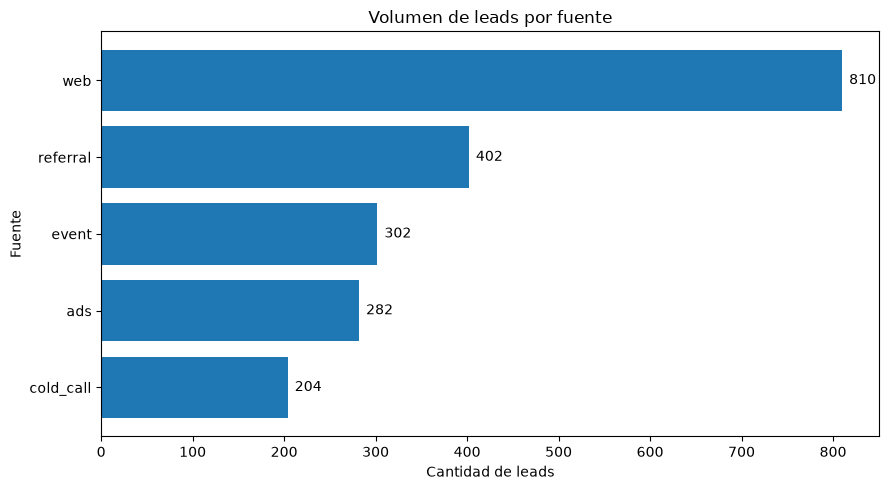

In [115]:
lead_volume_plot_df = (
    leads_df
    .sort_values("total_leads")
)

fig, ax = plt.subplots(figsize=(9, 5))

ax.barh(
    lead_volume_plot_df["source"],
    lead_volume_plot_df["total_leads"]
)

ax.set_title("Volumen de leads por fuente")
ax.set_xlabel("Cantidad de leads")
ax.set_ylabel("Fuente")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:,.0f}",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Relación entre score y conversión

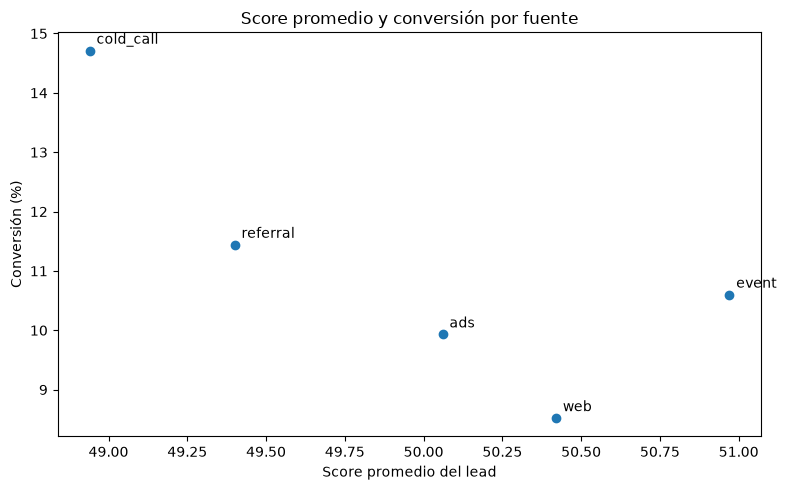

In [116]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    leads_df["average_lead_score"],
    leads_df["conversion_rate_pct"]
)

for _, row in leads_df.iterrows():
    ax.annotate(
        row["source"],
        (
            row["average_lead_score"],
            row["conversion_rate_pct"]
        ),
        xytext=(5, 5),
        textcoords="offset points"
    )

ax.set_title(
    "Score promedio y conversión por fuente"
)
ax.set_xlabel("Score promedio del lead")
ax.set_ylabel("Conversión (%)")

plt.tight_layout()
plt.show()

## Hallazgos de CRM
- Se analizaron 5.000 cuentas, 15.000 contactos y 3.000 oportunidades.
- Existen 2.221 oportunidades abiertas, 476 ganadas y 303 perdidas.
- La tasa de ganancia entre oportunidades cerradas es del 61,10 %.
- El pipeline abierto representa el mayor monto registrado en CRM.
- Se identificaron 1.029 oportunidades con fecha de cierre anterior a
  la fecha de creación, equivalentes al 34,30 % de las oportunidades.
- De las 6.000 relaciones entre oportunidades y contactos, 5.995 corresponden a cuentas diferentes.
- Se asignaron 17.019 actividades a cuentas y 2.981 actividades no
  tienen referencias suficientes para su atribución.
- El 10,25 % de los leads tiene estado actual "converted".
- La fuente "web" concentra el mayor volumen de leads, pero el volumen no implica necesariamente una mayor tasa de conversión.
- Los montos de CRM no incluyen una moneda explícita y no deben combinarse con los importes financieros de Billing.

# 5. Integración University–Billing
La vista "gold.vw_student_customer_360" relaciona a los estudiantes con los clientes de Billing mediante:
"student_id = external_ref"

Esta sección analiza de forma descriptiva la relación entre:
- Antecedentes de reprobación y abandono.
- Presencia de facturas.
- Suscripciones activas.
- Incidencias de conciliación financiera.
Los resultados muestran asociaciones dentro del dataset, pero no demuestran relaciones causales entre el comportamiento académico y financiero.

In [118]:
query_student_360 = """
SELECT *
FROM gold.vw_student_customer_360
ORDER BY student_id;
"""

student_360_df = ejecutar_consulta(
    query_student_360
)

print(
    f"Estudiantes integrados: "
    f"{len(student_360_df):,}"
)

student_360_df.head()

/tmp/ipykernel_2287/947915564.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  return pd.read_sql_query(


Estudiantes integrados: 5,000


,student_id,student_name,student_email,student_country,university_enrolled_at,total_enrollments,completed_enrollments,active_enrollments,failed_enrollments,dropped_enrollments,enrollments_with_grades,average_weighted_observed_score,customer_id,customer_name,customer_email,customer_country,segment,is_student_linked,total_subscriptions,active_subscriptions,paused_subscriptions,cancelled_subscriptions,temporally_invalid_subscriptions,active_subscriptions_to_inactive_products,billing_currency_count,total_invoices,paid_invoices,pending_invoices,overdue_invoices,total_payments,overpaid_invoices,underpaid_invoices,paid_status_but_underpaid,invoices_without_items,invoices_not_matching_item_total,has_failed_enrollment,has_dropped_enrollment,has_active_subscription,has_invoices,has_billing_reconciliation_issue
0,STU-0000001,Martina Diaz,martina.diaz5727@lake.local,US,2019-10-01,9,6,2,0,1,9,76.12,CUS-0000001,Carlos Contreras,carlos.contreras7090@example.com,CL,smb,True,1,1,0,0,1,0,4,7,5,2,0,7,3,4,2,1,6,False,True,True,True,True
1,STU-0000002,Manuel Torres,manuel.torres5619@mail.test,CL,2025-03-20,1,0,0,0,1,1,NaN,CUS-0000002,Maria Sandoval,maria.sandoval1480@lake.local,MX,retail,True,5,5,0,0,0,0,3,5,3,1,1,6,2,3,1,0,5,False,True,True,True,True
2,STU-0000003,Maximiliano Martinez,maximiliano.martinez7688@demo.io,PE,2022-10-19,6,3,1,1,1,5,72.37,CUS-0000003,Ignacio Torres,ignacio.torres8864@example.com,CL,retail,True,0,0,0,0,0,0,5,10,7,1,2,14,4,6,3,2,8,True,True,False,True,True
3,STU-0000004,Magdalena Vasquez,magdalena.vasquez8686@example.com,CL,2020-09-23,5,2,1,2,0,5,67.84,CUS-0000004,Juan Sandoval,juan.sandoval3659@demo.io,MX,smb,True,3,3,0,0,0,1,1,1,1,0,0,2,0,1,1,0,1,True,False,True,True,True
4,STU-0000005,Luis Rivera,luis.rivera9349@lake.local,CL,2025-07-28,3,1,1,0,1,3,84.76,CUS-0000005,Cristobal Reyes,cristobal.reyes1471@mail.test,CL,retail,True,1,1,0,0,0,0,3,5,3,2,0,7,2,3,1,1,4,False,True,True,True,True


In [119]:
student_360_numeric_columns = [
    "total_enrollments",
    "completed_enrollments",
    "active_enrollments",
    "failed_enrollments",
    "dropped_enrollments",
    "enrollments_with_grades",
    "average_weighted_observed_score",
    "total_subscriptions",
    "active_subscriptions",
    "paused_subscriptions",
    "cancelled_subscriptions",
    "billing_currency_count",
    "total_invoices",
    "paid_invoices",
    "pending_invoices",
    "overdue_invoices",
    "total_payments",
    "overpaid_invoices",
    "underpaid_invoices",
    "paid_status_but_underpaid",
    "invoices_without_items",
    "invoices_not_matching_item_total"
]

for column in student_360_numeric_columns:
    student_360_df[column] = pd.to_numeric(
        student_360_df[column]
    )

## Validar la integración

In [121]:
integration_validation_df = pd.DataFrame({
    "indicador": [
        "Total de estudiantes",
        "Estudiantes vinculados a clientes",
        "Estudiantes sin cliente",
        "Estudiantes con facturas",
        "Estudiantes con suscripción activa"
    ],
    "valor": [
        len(student_360_df),
        student_360_df["customer_id"].notna().sum(),
        student_360_df["customer_id"].isna().sum(),
        student_360_df["has_invoices"].sum(),
        student_360_df[
            "has_active_subscription"
        ].sum()
    ]
})

integration_validation_df

,indicador,valor
0,Total de estudiantes,5000
1,Estudiantes vinculados a clientes,5000
2,Estudiantes sin cliente,0
3,Estudiantes con facturas,4967
4,Estudiantes con suscripción activa,3399


## Clasificación académica integrada

In [122]:
def clasificar_antecedentes_academicos(row):
    tiene_reprobacion = (
        row["failed_enrollments"] > 0
    )

    tiene_abandono = (
        row["dropped_enrollments"] > 0
    )

    if tiene_reprobacion and tiene_abandono:
        return "Reprobación y abandono"

    if tiene_reprobacion:
        return "Solo reprobación"

    if tiene_abandono:
        return "Solo abandono"

    return "Sin reprobación ni abandono"


student_360_df["situacion_academica"] = (
    student_360_df.apply(
        clasificar_antecedentes_academicos,
        axis=1
    )
)

## Resumen por situación académica

In [123]:
student_360_summary_df = (
    student_360_df
    .groupby(
        "situacion_academica",
        as_index=False
    )
    .agg(
        estudiantes=(
            "student_id",
            "count"
        ),
        estudiantes_con_facturas=(
            "has_invoices",
            "sum"
        ),
        estudiantes_con_suscripcion_activa=(
            "has_active_subscription",
            "sum"
        ),
        estudiantes_con_incidencia_billing=(
            "has_billing_reconciliation_issue",
            "sum"
        ),
        promedio_facturas=(
            "total_invoices",
            "mean"
        ),
        promedio_suscripciones_activas=(
            "active_subscriptions",
            "mean"
        ),
        promedio_academico_observado=(
            "average_weighted_observed_score",
            "mean"
        )
    )
)

student_360_summary_df[
    "tasa_con_facturas_pct"
] = (
    student_360_summary_df[
        "estudiantes_con_facturas"
    ]
    / student_360_summary_df["estudiantes"]
    * 100
).round(2)

student_360_summary_df[
    "tasa_suscripcion_activa_pct"
] = (
    student_360_summary_df[
        "estudiantes_con_suscripcion_activa"
    ]
    / student_360_summary_df["estudiantes"]
    * 100
).round(2)

student_360_summary_df[
    "tasa_incidencia_billing_pct"
] = (
    student_360_summary_df[
        "estudiantes_con_incidencia_billing"
    ]
    / student_360_summary_df["estudiantes"]
    * 100
).round(2)

student_360_summary_df

,situacion_academica,estudiantes,estudiantes_con_facturas,estudiantes_con_suscripcion_activa,estudiantes_con_incidencia_billing,promedio_facturas,promedio_suscripciones_activas,promedio_academico_observado,tasa_con_facturas_pct,tasa_suscripcion_activa_pct,tasa_incidencia_billing_pct
0,Reprobación y abandono,775,769,519,769,4.94,1.15,75.05,99.23,66.97,99.23
1,Sin reprobación ni abandono,1806,1798,1243,1798,5.02,1.15,74.99,99.56,68.83,99.56
2,Solo abandono,1189,1178,814,1178,5.10,1.16,74.65,99.07,68.46,99.07
3,Solo reprobación,1230,1222,823,1222,4.97,1.10,74.76,99.35,66.91,99.35


## Gráfico de suscripción activa por antecedentes académicos

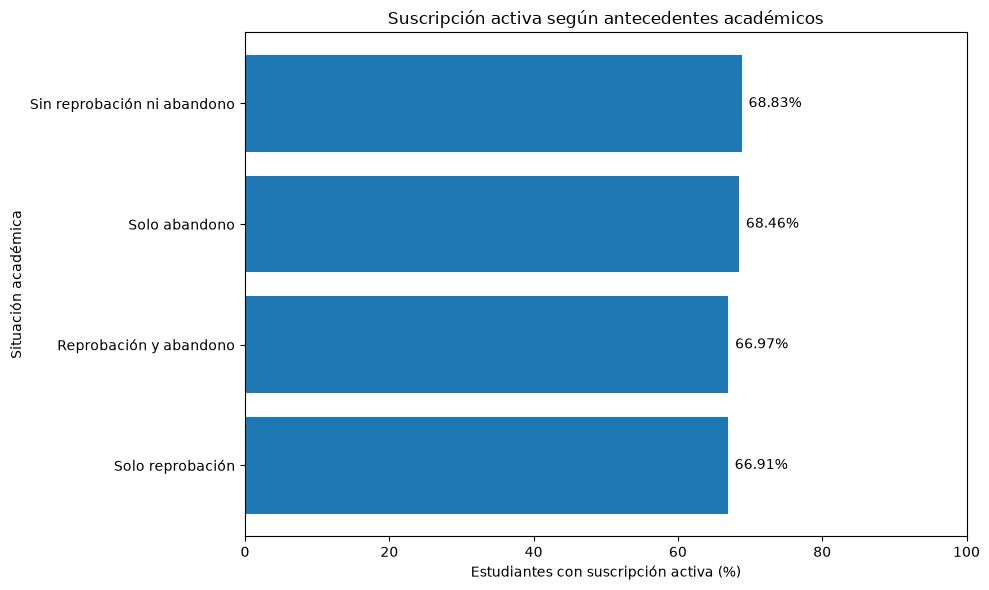

In [124]:
active_subscription_plot_df = (
    student_360_summary_df
    .sort_values(
        "tasa_suscripcion_activa_pct"
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    active_subscription_plot_df[
        "situacion_academica"
    ],
    active_subscription_plot_df[
        "tasa_suscripcion_activa_pct"
    ]
)

ax.set_title(
    "Suscripción activa según antecedentes académicos"
)
ax.set_xlabel(
    "Estudiantes con suscripción activa (%)"
)
ax.set_ylabel("Situación académica")
ax.set_xlim(0, 100)

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:.2f}%",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Gráfico de incidencias de Billing por antecedentes académicos

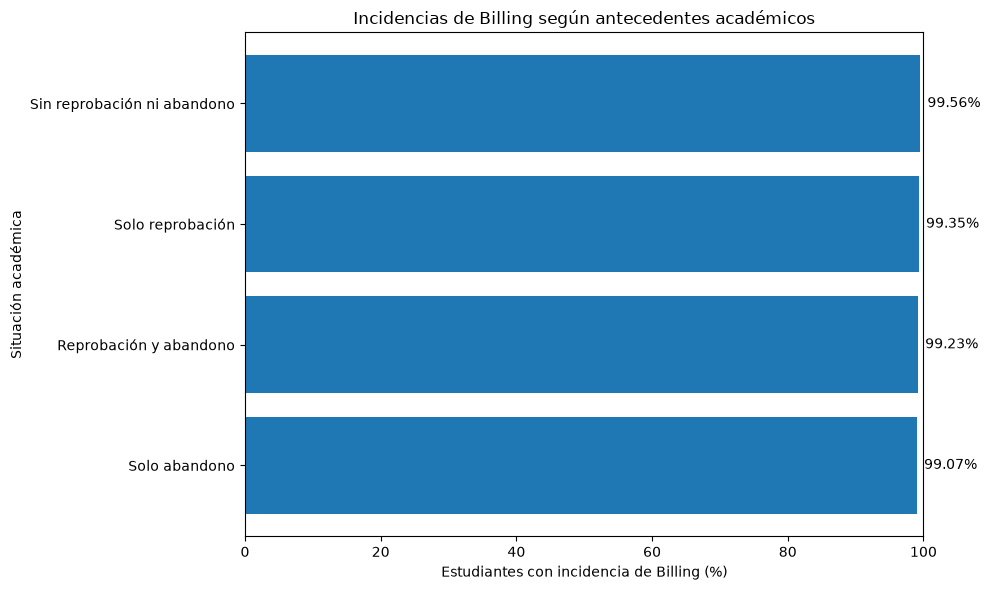

In [125]:
billing_issue_plot_df = (
    student_360_summary_df
    .sort_values(
        "tasa_incidencia_billing_pct"
    )
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    billing_issue_plot_df[
        "situacion_academica"
    ],
    billing_issue_plot_df[
        "tasa_incidencia_billing_pct"
    ]
)

ax.set_title(
    "Incidencias de Billing según antecedentes académicos"
)
ax.set_xlabel(
    "Estudiantes con incidencia de Billing (%)"
)
ax.set_ylabel("Situación académica")
ax.set_xlim(0, 100)

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:.2f}%",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Gráfico de promedio de facturas por situación académica

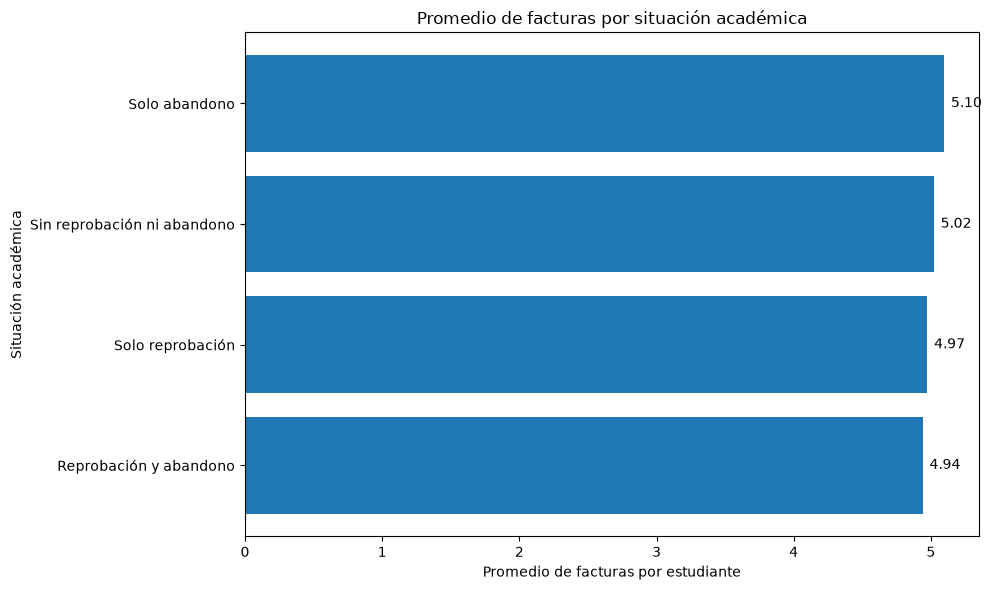

In [127]:
average_invoices_plot_df = (
    student_360_summary_df
    .sort_values("promedio_facturas")
)

fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    average_invoices_plot_df[
        "situacion_academica"
    ],
    average_invoices_plot_df[
        "promedio_facturas"
    ]
)

ax.set_title(
    "Promedio de facturas por situación académica"
)
ax.set_xlabel("Promedio de facturas por estudiante")
ax.set_ylabel("Situación académica")

for barra in ax.patches:
    valor = barra.get_width()

    ax.annotate(
        f"{valor:.2f}",
        (
            valor,
            barra.get_y()
            + barra.get_height() / 2
        ),
        va="center",
        xytext=(5, 0),
        textcoords="offset points"
    )

plt.tight_layout()
plt.show()

## Comparación según suscripción activa

In [128]:
subscription_academic_df = (
    student_360_df
    .groupby(
        "has_active_subscription",
        as_index=False
    )
    .agg(
        estudiantes=(
            "student_id",
            "count"
        ),
        promedio_inscripciones_completadas=(
            "completed_enrollments",
            "mean"
        ),
        promedio_inscripciones_reprobadas=(
            "failed_enrollments",
            "mean"
        ),
        promedio_inscripciones_abandonadas=(
            "dropped_enrollments",
            "mean"
        ),
        promedio_academico_observado=(
            "average_weighted_observed_score",
            "mean"
        )
    )
)

subscription_academic_df[
    "suscripcion_activa"
] = subscription_academic_df[
    "has_active_subscription"
].map({
    True: "Con suscripción activa",
    False: "Sin suscripción activa"
})

subscription_academic_df.drop(
    columns=["has_active_subscription"]
)

,estudiantes,promedio_inscripciones_completadas,promedio_inscripciones_reprobadas,promedio_inscripciones_abandonadas,promedio_academico_observado,suscripcion_activa
0,1601,2.96,0.53,0.50,74.92,Sin suscripción activa
1,3399,3.00,0.50,0.50,74.84,Con suscripción activa


Esta comparación es descriptiva, no se afirma que una suscripción provoque mejores o peores resultados académicos

## Incidencias financieras y situación académica

In [129]:
billing_academic_df = (
    student_360_df
    .groupby(
        "has_billing_reconciliation_issue",
        as_index=False
    )
    .agg(
        estudiantes=(
            "student_id",
            "count"
        ),
        promedio_inscripciones_completadas=(
            "completed_enrollments",
            "mean"
        ),
        promedio_inscripciones_reprobadas=(
            "failed_enrollments",
            "mean"
        ),
        promedio_inscripciones_abandonadas=(
            "dropped_enrollments",
            "mean"
        ),
        promedio_academico_observado=(
            "average_weighted_observed_score",
            "mean"
        )
    )
)

billing_academic_df[
    "situacion_billing"
] = billing_academic_df[
    "has_billing_reconciliation_issue"
].map({
    True: "Con incidencia de Billing",
    False: "Sin incidencia de Billing"
})

billing_academic_df.drop(
    columns=[
        "has_billing_reconciliation_issue"
    ]
)

,estudiantes,promedio_inscripciones_completadas,promedio_inscripciones_reprobadas,promedio_inscripciones_abandonadas,promedio_academico_observado,situacion_billing
0,33,2.97,0.61,0.58,73.86,Sin incidencia de Billing
1,4967,2.99,0.51,0.50,74.87,Con incidencia de Billing


## Hallazgos de la integración University–Billing
- Los 5.000 estudiantes tienen un cliente relacionado en Billing.
- Un total de 4.967 estudiantes tiene al menos una factura.
- Existen 3.399 estudiantes con al menos una suscripción activa.
- La integración permite comparar antecedentes académicos con características de facturación y suscripción.
- Las diferencias observadas entre grupos son descriptivas.
- El dataset no permite establecer que los antecedentes académicos provoquen determinados comportamientos financieros, ni lo contrario.
- Los importes financieros no se consolidan en esta vista porque los clientes pueden operar en diferentes monedas.

# 6. Conclusiones finales

El proyecto construyó un pipeline de datos que integra tres dominios:

- University
- Billing
- CRM

La arquitectura implementada sigue el flujo:

CSV → Bronze → Silver → Gold → KPIs y visualizaciones

## Principales resultados

### University

- Se procesaron 5.000 estudiantes, 300 cursos y 25.000 inscripciones.
- El 59,72 % de las inscripciones está completado.
- Las tasas de reprobación y abandono son cercanas al 10 %.
- El promedio ponderado observado utiliza únicamente las evaluaciones
  disponibles y no representa necesariamente una nota final oficial.

### Billing

- Se procesaron 50.000 facturas y 80.000 pagos.
- Se identificaron ocho monedas diferentes.
- Solo 8 facturas coinciden exactamente con sus pagos acumulados.
- Existen 20.482 facturas sobrepagadas y 29.510 subpagadas.
- El 41,40 % de las facturas con estado `paid` está subpagado.
- Los importes se mantienen separados por moneda.

### CRM

- Se procesaron 5.000 cuentas, 15.000 contactos y 3.000 oportunidades.
- La tasa de ganancia entre oportunidades cerradas es del 61,10 %.
- Se identificaron 1.029 oportunidades con inconsistencias temporales.
- De 6.000 relaciones oportunidad–contacto, 5.995 corresponden a
  cuentas diferentes.
- El 10,25 % de los leads tiene estado actual `converted`.

## Conclusión general

La solución conserva los datos de origen, incorpora indicadores de
calidad y genera modelos Gold preparados para análisis y dashboard.

Los principales problemas detectados no fueron eliminados
automáticamente. Se conservaron como indicadores descriptivos para
permitir su revisión y evitar modificar el significado original de los
datos.

## Cierre de conexión

In [130]:
if (
    "connection" in globals()
    and connection is not None
    and connection.closed == 0
):
    connection.close()

    print(
        "Conexión con PostgreSQL cerrada correctamente"
    )
else:
    print("No existe una conexión abierta")

Conexión con PostgreSQL cerrada correctamente
